In [1]:
from google.colab import files
uploaded = files.upload()

Saving metr-la.h5 to metr-la.h5


In [2]:
import os
import numpy as np
import pandas as pd

# ============================================================
# ROBUSTNESS TEST — PRE-SPECIFIED WINDOWS
# ============================================================

DATA_PATH = "/content/metr-la.h5"
SENSOR_ID = "773062"

CONTEXT_LENGTH = 96          # 8 hours
FORECAST_HORIZON = 24       # 2 hours
TOTAL_LENGTH = 120           # 10 hours
FREQ = "5min"

# IMPORTANT:
# These 10 windows are fixed BEFORE looking at any model outputs.
WINDOW_DATES = pd.date_range(
    "2012-06-04",
    periods=10,
    freq="D"
)

WINDOW_START_TIME = "13:30:00"

# ============================================================
# 1. LOAD DATA
# ============================================================

assert os.path.exists(DATA_PATH), "metr-la.h5 not found."

df = pd.read_hdf(DATA_PATH)

if isinstance(df.index, pd.DatetimeIndex):
    df.index.freq = None

column_lookup = {str(c): c for c in df.columns}

assert SENSOR_ID in column_lookup, \
    f"Sensor {SENSOR_ID} not found."

series = (
    df[column_lookup[SENSOR_ID]]
    .astype(float)
    .sort_index()
)

print("Dataset:", df.shape)
print("Sensor:", SENSOR_ID)
print()

# ============================================================
# 2. AUDIT ALL 10 WINDOWS
# ============================================================

audit_rows = []
all_window_rows = []

for i, date in enumerate(WINDOW_DATES, start=1):

    start = pd.Timestamp(
        f"{date.date()} {WINDOW_START_TIME}"
    )

    expected_index = pd.date_range(
        start=start,
        periods=TOTAL_LENGTH,
        freq=FREQ
    )

    window = series.reindex(expected_index)

    context = window.iloc[:CONTEXT_LENGTH]
    gt = window.iloc[CONTEXT_LENGTH:]

    context_nan = int(context.isna().sum())
    gt_nan = int(gt.isna().sum())

    context_zero = int((context == 0).sum())
    gt_zero = int((gt == 0).sum())

    context_finite = bool(
        np.isfinite(context.dropna().to_numpy()).all()
    )

    gt_finite = bool(
        np.isfinite(gt.dropna().to_numpy()).all()
    )

    clean = (
        len(context) == CONTEXT_LENGTH
        and len(gt) == FORECAST_HORIZON
        and context_nan == 0
        and gt_nan == 0
        and context_zero == 0
        and gt_zero == 0
        and context_finite
        and gt_finite
    )

    window_id = f"W{i:02d}"

    audit_rows.append({
        "window_id": window_id,
        "date": str(date.date()),
        "context_start": context.index[0],
        "context_end": context.index[-1],
        "forecast_start": gt.index[0],
        "forecast_end": gt.index[-1],
        "context_points": len(context),
        "forecast_points": len(gt),
        "context_nan": context_nan,
        "forecast_nan": gt_nan,
        "context_zero": context_zero,
        "forecast_zero": gt_zero,
        "clean": clean,
    })

    if clean:
        for ts, value in context.items():
            all_window_rows.append({
                "window_id": window_id,
                "timestamp": ts,
                "traffic_speed": float(value),
                "split": "context",
            })

        for ts, value in gt.items():
            all_window_rows.append({
                "window_id": window_id,
                "timestamp": ts,
                "traffic_speed": float(value),
                "split": "ground_truth",
            })

# ============================================================
# 3. CREATE AUDIT TABLE
# ============================================================

audit = pd.DataFrame(audit_rows)

clean_windows = audit[audit["clean"]].copy()
invalid_windows = audit[~audit["clean"]].copy()

print("==============================================")
print("ROBUSTNESS WINDOW AUDIT — SENSOR 773062")
print("==============================================")
print()
print(audit[
    [
        "window_id",
        "date",
        "context_nan",
        "forecast_nan",
        "context_zero",
        "forecast_zero",
        "clean",
    ]
].to_string(index=False))

print()
print("Pre-specified windows:", len(audit))
print("Clean windows:", len(clean_windows))
print("Invalid windows:", len(invalid_windows))

# ============================================================
# 4. SAVE — NO MODEL OUTPUTS INVOLVED
# ============================================================

audit.to_csv(
    "/content/robustness_window_audit.csv",
    index=False
)

locked_windows = pd.DataFrame(all_window_rows)

locked_windows.to_csv(
    "/content/robustness_windows_sensor_773062.csv",
    index=False
)

print()
print("Saved:")
print("/content/robustness_window_audit.csv")
print("/content/robustness_windows_sensor_773062.csv")

print()
print("Rows in locked clean-window dataset:", len(locked_windows))

if len(invalid_windows) == 0:
    print()
    print("✅ ALL 10 PRE-SPECIFIED WINDOWS ARE CLEAN")
    print("✅ ROBUSTNESS DATASET LOCKED BEFORE MODEL INFERENCE")
else:
    print()
    print("⚠️ SOME PRE-SPECIFIED WINDOWS FAILED DATA-QUALITY RULES")
    print("They will NOT be replaced based on model performance.")
    print("Stop here before running any model.")

Dataset: (34272, 207)
Sensor: 773062

ROBUSTNESS WINDOW AUDIT — SENSOR 773062

window_id       date  context_nan  forecast_nan  context_zero  forecast_zero  clean
      W01 2012-06-04            0             0             0              0   True
      W02 2012-06-05            0             0             9              0  False
      W03 2012-06-06            0             0             0              0   True
      W04 2012-06-07            0             0             0              0   True
      W05 2012-06-08            0             0             0              0   True
      W06 2012-06-09            0             0             5              0  False
      W07 2012-06-10            0             0            26              0  False
      W08 2012-06-11            0             0             0              0   True
      W09 2012-06-12            0             0             0              0   True
      W10 2012-06-13            0             0             0              0   Tr

In [3]:
from google.colab import files

files.download("/content/robustness_window_audit.csv")
files.download("/content/robustness_windows_sensor_773062.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import numpy as np
import pandas as pd

# ============================================================
# PERSISTENCE BASELINE — ROBUSTNESS WINDOWS
# ============================================================

DATA_PATH = "/content/robustness_windows_sensor_773062.csv"

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["timestamp"]
)

window_ids = sorted(df["window_id"].unique())

prediction_rows = []
metric_rows = []

for window_id in window_ids:

    window = df[df["window_id"] == window_id].copy()

    context = (
        window[window["split"] == "context"]
        .sort_values("timestamp")
    )

    gt = (
        window[window["split"] == "ground_truth"]
        .sort_values("timestamp")
    )

    assert len(context) == 96
    assert len(gt) == 24

    y_true = gt["traffic_speed"].to_numpy(dtype=float)

    # Persistence forecast:
    # Repeat the final observed context value for all 24 future steps.
    last_observed = float(
        context["traffic_speed"].iloc[-1]
    )

    prediction = np.repeat(
        last_observed,
        24
    )

    assert prediction.shape == (24,)
    assert np.isfinite(prediction).all()

    mae = np.mean(
        np.abs(y_true - prediction)
    )

    rmse = np.sqrt(
        np.mean((y_true - prediction) ** 2)
    )

    metric_rows.append({
        "window_id": window_id,
        "model": "Persistence",
        "mae": mae,
        "rmse": rmse,
    })

    for timestamp, actual, pred in zip(
        gt["timestamp"],
        y_true,
        prediction,
    ):
        prediction_rows.append({
            "window_id": window_id,
            "timestamp": timestamp,
            "ground_truth": actual,
            "persistence_prediction": pred,
        })

# ============================================================
# SAVE PER-WINDOW OUTPUTS
# ============================================================

predictions = pd.DataFrame(prediction_rows)
metrics = pd.DataFrame(metric_rows)

predictions.to_csv(
    "/content/robustness_persistence_predictions.csv",
    index=False
)

metrics.to_csv(
    "/content/robustness_persistence_metrics.csv",
    index=False
)

# ============================================================
# AGGREGATE SUMMARY
# ============================================================

summary = pd.DataFrame([{
    "model": "Persistence",
    "n_windows": len(metrics),

    "mean_mae": metrics["mae"].mean(),
    "std_mae": metrics["mae"].std(ddof=1),
    "median_mae": metrics["mae"].median(),

    "mean_rmse": metrics["rmse"].mean(),
    "std_rmse": metrics["rmse"].std(ddof=1),
    "median_rmse": metrics["rmse"].median(),
}])

summary.to_csv(
    "/content/robustness_persistence_summary.csv",
    index=False
)

print("======================================")
print("PERSISTENCE BASELINE — ROBUSTNESS")
print("======================================")
print()

print(metrics.to_string(index=False))

print()
print("--------------------------------------")
print("AGGREGATE")
print("--------------------------------------")
print(summary.to_string(index=False))

print()
print("Windows evaluated:", len(metrics))
print()

print("Saved:")
print("/content/robustness_persistence_predictions.csv")
print("/content/robustness_persistence_metrics.csv")
print("/content/robustness_persistence_summary.csv")

print()
print("✅ PERSISTENCE BASELINE COMPLETED")

PERSISTENCE BASELINE — ROBUSTNESS

window_id       model       mae      rmse
      W01 Persistence  1.708912  2.988945
      W03 Persistence 10.657903 10.746121
      W04 Persistence  1.922206  2.837681
      W05 Persistence  2.203125  2.890504
      W08 Persistence  1.921296  3.081078
      W09 Persistence 10.305556 14.958112
      W10 Persistence  3.450893  3.806045

--------------------------------------
AGGREGATE
--------------------------------------
      model  n_windows  mean_mae  std_mae  median_mae  mean_rmse  std_rmse  median_rmse
Persistence          7  4.595699 4.062456    2.203125   5.901212  4.912134     3.081078

Windows evaluated: 7

Saved:
/content/robustness_persistence_predictions.csv
/content/robustness_persistence_metrics.csv
/content/robustness_persistence_summary.csv

✅ PERSISTENCE BASELINE COMPLETED


In [5]:
from google.colab import files

files.download("/content/robustness_windows_sensor_773062.csv")
files.download("/content/robustness_window_audit.csv")
files.download("/content/robustness_persistence_predictions.csv")
files.download("/content/robustness_persistence_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!nvidia-smi

Fri Aug 14 15:52:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import files

uploaded = files.upload()

Saving robustness_persistence_metrics.csv to robustness_persistence_metrics.csv
Saving robustness_windows_sensor_773062.csv to robustness_windows_sensor_773062.csv


In [3]:
import os
import pandas as pd
import numpy as np

WINDOWS_PATH = "/content/robustness_windows_sensor_773062.csv"
BASELINE_PATH = "/content/robustness_persistence_metrics.csv"

assert os.path.exists(WINDOWS_PATH)
assert os.path.exists(BASELINE_PATH)

windows = pd.read_csv(WINDOWS_PATH, parse_dates=["timestamp"])
baseline = pd.read_csv(BASELINE_PATH)

expected_windows = ["W01", "W03", "W04", "W05", "W08", "W09", "W10"]

actual_windows = sorted(windows["window_id"].unique().tolist())

assert actual_windows == expected_windows, (
    f"Window mismatch: {actual_windows}"
)

for wid in expected_windows:
    w = windows[windows["window_id"] == wid]

    context = w[w["split"] == "context"]
    gt = w[w["split"] == "ground_truth"]

    assert len(context) == 96
    assert len(gt) == 24

    assert np.isfinite(context["traffic_speed"]).all()
    assert np.isfinite(gt["traffic_speed"]).all()

    assert (context["traffic_speed"] > 0).all()
    assert (gt["traffic_speed"] > 0).all()

assert sorted(baseline["window_id"].tolist()) == expected_windows

print("======================================")
print("ROBUSTNESS DATA RELOAD AUDIT")
print("======================================")
print("Clean windows:", actual_windows)
print("Number of windows:", len(actual_windows))
print("Rows:", len(windows))
print("Expected rows:", 7 * 120)
print("Persistence rows:", len(baseline))
print()
print("✅ 7 LOCKED WINDOWS VERIFIED")
print("✅ PERSISTENCE METRICS VERIFIED")

ROBUSTNESS DATA RELOAD AUDIT
Clean windows: ['W01', 'W03', 'W04', 'W05', 'W08', 'W09', 'W10']
Number of windows: 7
Rows: 840
Expected rows: 840
Persistence rows: 7

✅ 7 LOCKED WINDOWS VERIFIED
✅ PERSISTENCE METRICS VERIFIED


In [4]:
!pip install -q "timesfm[torch]==2.0.2"

import torch
import timesfm
import importlib.metadata as metadata

print("TimesFM package:", metadata.version("timesfm"))
print("CUDA available:", torch.cuda.is_available())

assert metadata.version("timesfm") == "2.0.2"
assert torch.cuda.is_available(), "CUDA is not available."

print("GPU:", torch.cuda.get_device_name(0))
print("✅ TIMESFM 2.5 ROBUSTNESS ENV READY")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
TimesFM package: 2.0.2
CUDA available: True
GPU: Tesla T4
✅ TIMESFM 2.5 ROBUSTNESS ENV READY


In [5]:
import time
import numpy as np
import pandas as pd
import torch
import timesfm

# ============================================================
# TIMESFM 2.5 — ROBUSTNESS TEST
# 7 PRE-SPECIFIED CLEAN WINDOWS
# ============================================================

MODEL_ID = "google/timesfm-2.5-200m-pytorch"
WINDOWS_PATH = "/content/robustness_windows_sensor_773062.csv"

PRED_PATH = "/content/robustness_timesfm_predictions.csv"
METRICS_PATH = "/content/robustness_timesfm_metrics.csv"
AUDIT_PATH = "/content/robustness_timesfm_output_audit.csv"
SUMMARY_PATH = "/content/robustness_timesfm_summary.csv"

EXPECTED_WINDOWS = [
    "W01", "W03", "W04", "W05", "W08", "W09", "W10"
]

CONTEXT_LENGTH = 96
FORECAST_HORIZON = 24

# ============================================================
# 1. LOAD LOCKED WINDOWS
# ============================================================

df = pd.read_csv(
    WINDOWS_PATH,
    parse_dates=["timestamp"]
)

actual_windows = sorted(df["window_id"].unique().tolist())

assert actual_windows == EXPECTED_WINDOWS
assert len(df) == 7 * 120

print("Locked robustness dataset: OK")
print("Windows:", actual_windows)

# ============================================================
# 2. LOAD TIMESFM ONCE
# ============================================================

assert torch.cuda.is_available()
print("GPU:", torch.cuda.get_device_name(0))

print("\nLoading:", MODEL_ID)

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    MODEL_ID
)

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

print("TimesFM 2.5 model: OK")

# ============================================================
# 3. RUN ALL 7 WINDOWS — NO PERFORMANCE-BASED EXCLUSION
# ============================================================

prediction_rows = []
metric_rows = []
audit_rows = []

for window_id in EXPECTED_WINDOWS:

    window = df[df["window_id"] == window_id].copy()

    context_df = (
        window[window["split"] == "context"]
        .sort_values("timestamp")
    )

    gt_df = (
        window[window["split"] == "ground_truth"]
        .sort_values("timestamp")
    )

    assert len(context_df) == CONTEXT_LENGTH
    assert len(gt_df) == FORECAST_HORIZON

    context = context_df["traffic_speed"].to_numpy(
        dtype=np.float32
    )

    y_true = gt_df["traffic_speed"].to_numpy(
        dtype=np.float64
    )

    assert np.isfinite(context).all()
    assert np.isfinite(y_true).all()

    # --------------------------------------------------------
    # Forecast
    # --------------------------------------------------------

    start = time.perf_counter()

    with torch.no_grad():
        point_forecast, quantile_forecast = model.forecast(
            horizon=FORECAST_HORIZON,
            inputs=[context],
        )

    elapsed = time.perf_counter() - start

    point = np.asarray(
        point_forecast[0],
        dtype=np.float64
    )

    quantiles = np.asarray(
        quantile_forecast[0],
        dtype=np.float64
    )

    shape_ok = (
        point.shape == (24,)
        and quantiles.shape[0] == 24
        and quantiles.shape[1] >= 6
    )

    if shape_ok:
        q50 = quantiles[:, 5]
    else:
        q50 = np.full(24, np.nan)

    point_finite = bool(np.isfinite(point).all())
    q50_finite = bool(np.isfinite(q50).all())

    if point_finite and q50_finite:
        max_diff = float(
            np.max(np.abs(point - q50))
        )

        point_equals_q50 = bool(
            np.allclose(
                point,
                q50,
                atol=1e-5,
                rtol=1e-5
            )
        )
    else:
        max_diff = np.nan
        point_equals_q50 = False

    valid_output = (
        shape_ok
        and point_finite
        and q50_finite
        and point_equals_q50
    )

    # IMPORTANT:
    # A failed clean window remains in the audit.
    # It is NOT dropped or replaced.
    if valid_output:

        prediction = q50.copy()

        mae = np.mean(
            np.abs(y_true - prediction)
        )

        rmse = np.sqrt(
            np.mean(
                (y_true - prediction) ** 2
            )
        )

    else:
        prediction = q50.copy()
        mae = np.nan
        rmse = np.nan

    # --------------------------------------------------------
    # Save per-window audit
    # --------------------------------------------------------

    audit_rows.append({
        "window_id": window_id,
        "shape_ok": shape_ok,
        "point_finite": point_finite,
        "q50_finite": q50_finite,
        "point_equals_q50": point_equals_q50,
        "point_q50_max_abs_diff": max_diff,
        "valid_output": valid_output,
        "inference_seconds": elapsed,
    })

    metric_rows.append({
        "window_id": window_id,
        "model": "TimesFM",
        "version": "2.5",
        "mae": mae,
        "rmse": rmse,
        "valid_output": valid_output,
    })

    for timestamp, actual, pred in zip(
        gt_df["timestamp"],
        y_true,
        prediction,
    ):
        prediction_rows.append({
            "window_id": window_id,
            "timestamp": timestamp,
            "ground_truth": actual,
            "timesfm_2_5": pred,
        })

    status = "PASS" if valid_output else "FAIL"

    print(
        f"{window_id}: {status} | "
        f"MAE={mae:.4f} | RMSE={rmse:.4f}"
        if valid_output
        else f"{window_id}: FAIL — invalid TimesFM output"
    )

# ============================================================
# 4. SAVE RAW RESULTS BEFORE AGGREGATION
# ============================================================

predictions = pd.DataFrame(prediction_rows)
metrics = pd.DataFrame(metric_rows)
audit = pd.DataFrame(audit_rows)

predictions.to_csv(PRED_PATH, index=False)
metrics.to_csv(METRICS_PATH, index=False)
audit.to_csv(AUDIT_PATH, index=False)

print("\n======================================")
print("TIMESFM OUTPUT AUDIT")
print("======================================")

print(
    audit[
        [
            "window_id",
            "shape_ok",
            "point_finite",
            "q50_finite",
            "point_equals_q50",
            "point_q50_max_abs_diff",
            "valid_output",
        ]
    ].to_string(index=False)
)

# ============================================================
# 5. STRICT ROBUSTNESS COMPLETION CHECK
# ============================================================

valid_count = int(audit["valid_output"].sum())

print()
print("Valid TimesFM windows:", valid_count, "/ 7")

if valid_count != 7:

    print()
    print("❌ TIMESFM DID NOT PRODUCE VALID OUTPUT FOR ALL LOCKED WINDOWS")
    print("No window will be removed or replaced.")
    print("Audit saved:", AUDIT_PATH)

    raise RuntimeError(
        f"TimesFM valid outputs: {valid_count}/7"
    )

# ============================================================
# 6. AGGREGATE ONLY AFTER ALL 7 PASS
# ============================================================

summary = pd.DataFrame([{
    "model": "TimesFM",
    "version": "2.5",
    "n_windows": len(metrics),

    "mean_mae": metrics["mae"].mean(),
    "std_mae": metrics["mae"].std(ddof=1),
    "median_mae": metrics["mae"].median(),

    "mean_rmse": metrics["rmse"].mean(),
    "std_rmse": metrics["rmse"].std(ddof=1),
    "median_rmse": metrics["rmse"].median(),
}])

summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print()
print("======================================")
print("TIMESFM 2.5 ROBUSTNESS SUMMARY")
print("======================================")

print()
print(metrics[
    ["window_id", "mae", "rmse"]
].to_string(index=False))

print()
print("--------------------------------------")
print("AGGREGATE")
print("--------------------------------------")
print(summary.to_string(index=False))

print()
print("Saved:")
print(PRED_PATH)
print(METRICS_PATH)
print(AUDIT_PATH)
print(SUMMARY_PATH)

print()
print("✅ ALL 7 TIMESFM ROBUSTNESS WINDOWS PASSED")

Locked robustness dataset: OK
Windows: ['W01', 'W03', 'W04', 'W05', 'W08', 'W09', 'W10']
GPU: Tesla T4

Loading: google/timesfm-2.5-200m-pytorch


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  925MB            

model.safetensors: downloading bytes:           |  0.00B            

TimesFM 2.5 model: OK
W01: PASS | MAE=2.3031 | RMSE=2.9794
W03: PASS | MAE=4.3409 | RMSE=4.5920
W04: PASS | MAE=2.4355 | RMSE=2.8845
W05: PASS | MAE=2.2335 | RMSE=2.9507
W08: PASS | MAE=2.1869 | RMSE=2.9927
W09: PASS | MAE=9.5652 | RMSE=12.3533
W10: PASS | MAE=3.6065 | RMSE=3.9263

TIMESFM OUTPUT AUDIT
window_id  shape_ok  point_finite  q50_finite  point_equals_q50  point_q50_max_abs_diff  valid_output
      W01      True          True        True              True                     0.0          True
      W03      True          True        True              True                     0.0          True
      W04      True          True        True              True                     0.0          True
      W05      True          True        True              True                     0.0          True
      W08      True          True        True              True                     0.0          True
      W09      True          True        True              True                     

In [6]:
from google.colab import files

files.download("/content/robustness_timesfm_predictions.csv")
files.download("/content/robustness_timesfm_metrics.csv")
files.download("/content/robustness_timesfm_output_audit.csv")
files.download("/content/robustness_timesfm_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# ============================================================
# MOIRAI 2.0 ROBUSTNESS — ISOLATED CLEAN ENVIRONMENT
# ============================================================

!rm -rf /content/moirai2_robust_env

!python -m pip install -q virtualenv
!python -m virtualenv /content/moirai2_robust_env

print("\n--- Installing compatible PyTorch CPU ---")
!/content/moirai2_robust_env/bin/pip install --no-cache-dir \
    "torch==2.4.1+cpu" \
    --index-url https://download.pytorch.org/whl/cpu

print("\n--- Installing Uni2TS 2.0.0 ---")
!/content/moirai2_robust_env/bin/pip install --no-cache-dir \
    "uni2ts==2.0.0"

print("\n--- Dependency audit ---")
!/content/moirai2_robust_env/bin/pip check

print("\n--- API audit ---")
!/content/moirai2_robust_env/bin/python -c "import torch, importlib.metadata as m; from uni2ts.model.moirai2 import Moirai2Forecast, Moirai2Module; print('Torch:', torch.__version__); print('Uni2TS:', m.version('uni2ts')); print('Moirai 2 API: OK')"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 41.5 MB/s eta 0:00:00
created virtual environment CPython3.12.13.final.0-64-x86_64 in 485ms
  creator CPython3Posix(dest=/content/moirai2_robust_env, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.2.1
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator

--- Installing compatible PyTorch CPU ---
Looking in indexes: https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 289.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 106.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 233.8 MB/s  0:00:00
  

In [8]:
%%writefile /content/run_moirai2_robustness.py

import time
import numpy as np
import pandas as pd
import torch

from uni2ts.model.moirai2 import Moirai2Forecast, Moirai2Module

# ============================================================
# MOIRAI 2.0 — ROBUSTNESS TEST
# 7 PRE-SPECIFIED CLEAN WINDOWS
# ============================================================

MODEL_ID = "Salesforce/moirai-2.0-R-small"
WINDOWS_PATH = "/content/robustness_windows_sensor_773062.csv"

PRED_PATH = "/content/robustness_moirai2_predictions.csv"
METRICS_PATH = "/content/robustness_moirai2_metrics.csv"
AUDIT_PATH = "/content/robustness_moirai2_output_audit.csv"
SUMMARY_PATH = "/content/robustness_moirai2_summary.csv"

EXPECTED_WINDOWS = [
    "W01", "W03", "W04", "W05", "W08", "W09", "W10"
]

CONTEXT_LENGTH = 96
FORECAST_HORIZON = 24

np.random.seed(42)
torch.manual_seed(42)

# ============================================================
# 1. LOAD LOCKED WINDOWS
# ============================================================

df = pd.read_csv(
    WINDOWS_PATH,
    parse_dates=["timestamp"]
)

actual_windows = sorted(df["window_id"].unique().tolist())

assert actual_windows == EXPECTED_WINDOWS
assert len(df) == 7 * 120

print("Locked robustness dataset: OK")
print("Windows:", actual_windows)

# ============================================================
# 2. LOAD MOIRAI 2.0 ONCE
# ============================================================

print("\nLoading:", MODEL_ID)

module = Moirai2Module.from_pretrained(
    MODEL_ID
)

model = Moirai2Forecast(
    module=module,
    prediction_length=FORECAST_HORIZON,
    context_length=CONTEXT_LENGTH,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

model = model.to("cpu")
model.eval()

quantile_levels = list(module.quantile_levels)

assert len(quantile_levels) == 9
assert 0.5 in quantile_levels

median_idx = quantile_levels.index(0.5)

print("Moirai 2.0 model: OK")
print("Quantiles:", quantile_levels)
print("q=0.5 index:", median_idx)

# ============================================================
# 3. RUN ALL 7 WINDOWS
# ============================================================

prediction_rows = []
metric_rows = []
audit_rows = []

for window_id in EXPECTED_WINDOWS:

    window = df[df["window_id"] == window_id].copy()

    context_df = (
        window[window["split"] == "context"]
        .sort_values("timestamp")
    )

    gt_df = (
        window[window["split"] == "ground_truth"]
        .sort_values("timestamp")
    )

    assert len(context_df) == CONTEXT_LENGTH
    assert len(gt_df) == FORECAST_HORIZON

    context = context_df["traffic_speed"].to_numpy(
        dtype=np.float32
    )

    y_true = gt_df["traffic_speed"].to_numpy(
        dtype=np.float64
    )

    assert context.shape == (96,)
    assert y_true.shape == (24,)

    assert np.isfinite(context).all()
    assert np.isfinite(y_true).all()

    # --------------------------------------------------------
    # ZERO-SHOT FORECAST
    # --------------------------------------------------------

    start = time.perf_counter()

    with torch.no_grad():
        forecast = model.predict(
            [context]
        )

    elapsed = time.perf_counter() - start

    forecast = np.asarray(forecast)

    shape_ok = (
        forecast.shape == (1, 9, 24)
    )

    if shape_ok:
        prediction = forecast[
            0,
            median_idx,
            :
        ].astype(np.float64)
    else:
        prediction = np.full(
            FORECAST_HORIZON,
            np.nan
        )

    prediction_finite = bool(
        np.isfinite(prediction).all()
    )

    valid_output = (
        shape_ok
        and prediction.shape == (24,)
        and prediction_finite
    )

    # IMPORTANT:
    # Any failed clean window remains in the audit.
    # No replacement / no performance-based exclusion.
    if valid_output:

        mae = np.mean(
            np.abs(y_true - prediction)
        )

        rmse = np.sqrt(
            np.mean(
                (y_true - prediction) ** 2
            )
        )

    else:
        mae = np.nan
        rmse = np.nan

    # --------------------------------------------------------
    # AUDIT
    # --------------------------------------------------------

    audit_rows.append({
        "window_id": window_id,
        "forecast_shape": str(forecast.shape),
        "shape_ok": shape_ok,
        "prediction_finite": prediction_finite,
        "valid_output": valid_output,
        "inference_seconds": elapsed,
    })

    metric_rows.append({
        "window_id": window_id,
        "model": "Moirai",
        "version": "2.0",
        "mae": mae,
        "rmse": rmse,
        "valid_output": valid_output,
    })

    for timestamp, actual, pred in zip(
        gt_df["timestamp"],
        y_true,
        prediction,
    ):
        prediction_rows.append({
            "window_id": window_id,
            "timestamp": timestamp,
            "ground_truth": actual,
            "moirai_2_0": pred,
        })

    if valid_output:
        print(
            f"{window_id}: PASS | "
            f"MAE={mae:.4f} | "
            f"RMSE={rmse:.4f}"
        )
    else:
        print(
            f"{window_id}: FAIL — invalid Moirai output"
        )

# ============================================================
# 4. SAVE RAW RESULTS
# ============================================================

predictions = pd.DataFrame(prediction_rows)
metrics = pd.DataFrame(metric_rows)
audit = pd.DataFrame(audit_rows)

predictions.to_csv(
    PRED_PATH,
    index=False
)

metrics.to_csv(
    METRICS_PATH,
    index=False
)

audit.to_csv(
    AUDIT_PATH,
    index=False
)

# ============================================================
# 5. OUTPUT AUDIT
# ============================================================

print("\n======================================")
print("MOIRAI 2.0 OUTPUT AUDIT")
print("======================================")

print(
    audit[
        [
            "window_id",
            "forecast_shape",
            "shape_ok",
            "prediction_finite",
            "valid_output",
        ]
    ].to_string(index=False)
)

valid_count = int(
    audit["valid_output"].sum()
)

print()
print(
    "Valid Moirai windows:",
    valid_count,
    "/ 7"
)

# ============================================================
# 6. STRICT COMPLETION CHECK
# ============================================================

if valid_count != 7:

    print()
    print(
        "❌ MOIRAI DID NOT PRODUCE VALID OUTPUT "
        "FOR ALL LOCKED WINDOWS"
    )

    print(
        "No window will be removed or replaced."
    )

    print(
        "Audit saved:",
        AUDIT_PATH
    )

    raise RuntimeError(
        f"Moirai valid outputs: {valid_count}/7"
    )

# ============================================================
# 7. AGGREGATE ONLY AFTER ALL 7 PASS
# ============================================================

summary = pd.DataFrame([{
    "model": "Moirai",
    "version": "2.0",
    "n_windows": len(metrics),

    "mean_mae": metrics["mae"].mean(),
    "std_mae": metrics["mae"].std(ddof=1),
    "median_mae": metrics["mae"].median(),

    "mean_rmse": metrics["rmse"].mean(),
    "std_rmse": metrics["rmse"].std(ddof=1),
    "median_rmse": metrics["rmse"].median(),
}])

summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print()
print("======================================")
print("MOIRAI 2.0 ROBUSTNESS SUMMARY")
print("======================================")

print()
print(
    metrics[
        ["window_id", "mae", "rmse"]
    ].to_string(index=False)
)

print()
print("--------------------------------------")
print("AGGREGATE")
print("--------------------------------------")

print(
    summary.to_string(index=False)
)

print()
print("Saved:")
print(PRED_PATH)
print(METRICS_PATH)
print(AUDIT_PATH)
print(SUMMARY_PATH)

print()
print("✅ ALL 7 MOIRAI ROBUSTNESS WINDOWS PASSED")

Writing /content/run_moirai2_robustness.py


In [9]:
!/content/moirai2_robust_env/bin/python /content/run_moirai2_robustness.py

Locked robustness dataset: OK
Windows: ['W01', 'W03', 'W04', 'W05', 'W08', 'W09', 'W10']

Loading: Salesforce/moirai-2.0-R-small



Moirai 2.0 model: OK
Quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
q=0.5 index: 4
W01: PASS | MAE=1.6552 | RMSE=2.7551
W03: PASS | MAE=5.5595 | RMSE=5.7751
W04: PASS | MAE=2.1011 | RMSE=2.8161
W05: PASS | MAE=1.9945 | RMSE=3.0175
W08: PASS | MAE=2.0226 | RMSE=2.9119
W09: PASS | MAE=9.6352 | RMSE=13.3023
W10: PASS | MAE=2.0551 | RMSE=2.8983

MOIRAI 2.0 OUTPUT AUDIT
window_id forecast_shape  shape_ok  prediction_finite  valid_output
      W01     (1, 9, 24)      True               True          True
      W03     (1, 9, 24)      True               True          True
      W04     (1, 9, 24)      True               True          True
      W05     (1, 9, 24)      True               True          True
      W08     (1, 9, 24)      True               True          True
      W09     (1, 9, 24)      True               True          True
      W10     

In [10]:
import numpy as np
import pandas as pd

# ============================================================
# FINAL ROBUSTNESS COMPARISON
# Persistence vs TimesFM 2.5 vs Moirai 2.0
# ============================================================

PERSISTENCE_PATH = "/content/robustness_persistence_metrics.csv"
TIMESFM_PATH = "/content/robustness_timesfm_metrics.csv"
MOIRAI_PATH = "/content/robustness_moirai2_metrics.csv"

EXPECTED_WINDOWS = [
    "W01", "W03", "W04", "W05", "W08", "W09", "W10"
]

# ============================================================
# 1. LOAD
# ============================================================

p = pd.read_csv(PERSISTENCE_PATH)
t = pd.read_csv(TIMESFM_PATH)
m = pd.read_csv(MOIRAI_PATH)

# ============================================================
# 2. STRICT INTEGRITY AUDIT
# ============================================================

assert sorted(p["window_id"].tolist()) == EXPECTED_WINDOWS
assert sorted(t["window_id"].tolist()) == EXPECTED_WINDOWS
assert sorted(m["window_id"].tolist()) == EXPECTED_WINDOWS

assert len(p) == 7
assert len(t) == 7
assert len(m) == 7

assert np.isfinite(p["mae"]).all()
assert np.isfinite(p["rmse"]).all()

assert t["valid_output"].all()
assert m["valid_output"].all()

assert np.isfinite(t["mae"]).all()
assert np.isfinite(t["rmse"]).all()

assert np.isfinite(m["mae"]).all()
assert np.isfinite(m["rmse"]).all()

print("✅ All three methods evaluated on the same 7 locked windows")

# ============================================================
# 3. BUILD CLEAN LONG-FORM TABLE
# ============================================================

p_clean = pd.DataFrame({
    "window_id": p["window_id"],
    "model": "Persistence",
    "version": "Baseline",
    "mae": p["mae"],
    "rmse": p["rmse"],
})

t_clean = pd.DataFrame({
    "window_id": t["window_id"],
    "model": "TimesFM",
    "version": "2.5",
    "mae": t["mae"],
    "rmse": t["rmse"],
})

m_clean = pd.DataFrame({
    "window_id": m["window_id"],
    "model": "Moirai",
    "version": "2.0",
    "mae": m["mae"],
    "rmse": m["rmse"],
})

final_metrics = pd.concat(
    [p_clean, t_clean, m_clean],
    ignore_index=True
)

assert len(final_metrics) == 21

# ============================================================
# 4. AGGREGATE STATISTICS
# ============================================================

summary = (
    final_metrics
    .groupby(["model", "version"], as_index=False)
    .agg(
        n_windows=("window_id", "count"),

        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        median_mae=("mae", "median"),

        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        median_rmse=("rmse", "median"),
    )
)

# Desired presentation order
order = {
    "Persistence": 0,
    "TimesFM": 1,
    "Moirai": 2,
}

summary["_order"] = summary["model"].map(order)
summary = (
    summary
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)

# ============================================================
# 5. IMPROVEMENT RELATIVE TO PERSISTENCE
# ============================================================

baseline = summary[
    summary["model"] == "Persistence"
].iloc[0]

summary["mean_mae_improvement_vs_persistence_pct"] = (
    100.0 *
    (baseline["mean_mae"] - summary["mean_mae"])
    / baseline["mean_mae"]
)

summary["mean_rmse_improvement_vs_persistence_pct"] = (
    100.0 *
    (baseline["mean_rmse"] - summary["mean_rmse"])
    / baseline["mean_rmse"]
)

# Baseline compared with itself
summary.loc[
    summary["model"] == "Persistence",
    [
        "mean_mae_improvement_vs_persistence_pct",
        "mean_rmse_improvement_vs_persistence_pct",
    ]
] = 0.0

# ============================================================
# 6. PER-WINDOW WINNERS
# ============================================================

mae_wide = final_metrics.pivot(
    index="window_id",
    columns="model",
    values="mae"
).loc[EXPECTED_WINDOWS]

rmse_wide = final_metrics.pivot(
    index="window_id",
    columns="model",
    values="rmse"
).loc[EXPECTED_WINDOWS]

winners = pd.DataFrame({
    "window_id": EXPECTED_WINDOWS,
    "mae_winner": mae_wide.idxmin(axis=1).values,
    "rmse_winner": rmse_wide.idxmin(axis=1).values,
})

mae_win_counts = (
    winners["mae_winner"]
    .value_counts()
    .reindex(
        ["Persistence", "TimesFM", "Moirai"],
        fill_value=0
    )
)

rmse_win_counts = (
    winners["rmse_winner"]
    .value_counts()
    .reindex(
        ["Persistence", "TimesFM", "Moirai"],
        fill_value=0
    )
)

win_summary = pd.DataFrame({
    "model": ["Persistence", "TimesFM", "Moirai"],
    "mae_window_wins": [
        mae_win_counts["Persistence"],
        mae_win_counts["TimesFM"],
        mae_win_counts["Moirai"],
    ],
    "rmse_window_wins": [
        rmse_win_counts["Persistence"],
        rmse_win_counts["TimesFM"],
        rmse_win_counts["Moirai"],
    ],
})

# ============================================================
# 7. SAVE FINAL ROBUSTNESS ARTIFACTS
# ============================================================

final_metrics.to_csv(
    "/content/robustness_final_metrics.csv",
    index=False
)

summary.to_csv(
    "/content/robustness_final_summary.csv",
    index=False
)

winners.to_csv(
    "/content/robustness_window_winners.csv",
    index=False
)

win_summary.to_csv(
    "/content/robustness_win_summary.csv",
    index=False
)

# ============================================================
# 8. REPORT
# ============================================================

print()
print("========================================================")
print("FINAL ROBUSTNESS COMPARISON — 7 LOCKED CLEAN WINDOWS")
print("========================================================")
print()

print(
    summary[
        [
            "model",
            "version",
            "n_windows",
            "mean_mae",
            "std_mae",
            "median_mae",
            "mean_rmse",
            "std_rmse",
            "median_rmse",
        ]
    ].to_string(index=False)
)

print()
print("----------------------------------------")
print("IMPROVEMENT VS PERSISTENCE")
print("----------------------------------------")

print(
    summary[
        [
            "model",
            "mean_mae_improvement_vs_persistence_pct",
            "mean_rmse_improvement_vs_persistence_pct",
        ]
    ].to_string(index=False)
)

print()
print("----------------------------------------")
print("PER-WINDOW WINNERS")
print("----------------------------------------")

print(winners.to_string(index=False))

print()
print("----------------------------------------")
print("WIN COUNTS")
print("----------------------------------------")

print(win_summary.to_string(index=False))

print()
print("Saved:")
print("/content/robustness_final_metrics.csv")
print("/content/robustness_final_summary.csv")
print("/content/robustness_window_winners.csv")
print("/content/robustness_win_summary.csv")

print()
print("✅ FINAL ROBUSTNESS COMPARISON VERIFIED")

✅ All three methods evaluated on the same 7 locked windows

FINAL ROBUSTNESS COMPARISON — 7 LOCKED CLEAN WINDOWS

      model  version  n_windows  mean_mae  std_mae  median_mae  mean_rmse  std_rmse  median_rmse
Persistence Baseline          7  4.595699 4.062456    2.203125   5.901212  4.912134     3.081078
    TimesFM      2.5          7  3.810230 2.668519    2.435476   4.668418  3.449803     2.992741
     Moirai      2.0          7  3.574755 2.992791    2.055143   4.782316  3.909698     2.911859

----------------------------------------
IMPROVEMENT VS PERSISTENCE
----------------------------------------
      model  mean_mae_improvement_vs_persistence_pct  mean_rmse_improvement_vs_persistence_pct
Persistence                                 0.000000                                  0.000000
    TimesFM                                17.091378                                 20.890533
     Moirai                                22.215202                                 18.960443

-------

In [11]:
import os
import zipfile

files_to_save = [
    # Locked experiment design
    "/content/robustness_window_audit.csv",
    "/content/robustness_windows_sensor_773062.csv",

    # Persistence
    "/content/robustness_persistence_predictions.csv",
    "/content/robustness_persistence_metrics.csv",
    "/content/robustness_persistence_summary.csv",

    # TimesFM 2.5
    "/content/robustness_timesfm_predictions.csv",
    "/content/robustness_timesfm_metrics.csv",
    "/content/robustness_timesfm_output_audit.csv",
    "/content/robustness_timesfm_summary.csv",

    # Moirai 2.0
    "/content/robustness_moirai2_predictions.csv",
    "/content/robustness_moirai2_metrics.csv",
    "/content/robustness_moirai2_output_audit.csv",
    "/content/robustness_moirai2_summary.csv",

    # FINAL robustness comparison
    "/content/robustness_final_metrics.csv",
    "/content/robustness_final_summary.csv",
    "/content/robustness_window_winners.csv",
    "/content/robustness_win_summary.csv",

    # Reproducibility
    "/content/run_moirai2_robustness.py",
]

existing = [p for p in files_to_save if os.path.exists(p)]

zip_path = "/content/urbanverse_robustness_FINAL_backup.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for path in existing:
        z.write(path, arcname=os.path.basename(path))

print("======================================")
print("FINAL BACKUP")
print("======================================")
print("Files backed up:", len(existing))

for path in existing:
    print("✅", os.path.basename(path))

print("\nSaved:", zip_path)

FINAL BACKUP
Files backed up: 15
✅ robustness_windows_sensor_773062.csv
✅ robustness_persistence_metrics.csv
✅ robustness_timesfm_predictions.csv
✅ robustness_timesfm_metrics.csv
✅ robustness_timesfm_output_audit.csv
✅ robustness_timesfm_summary.csv
✅ robustness_moirai2_predictions.csv
✅ robustness_moirai2_metrics.csv
✅ robustness_moirai2_output_audit.csv
✅ robustness_moirai2_summary.csv
✅ robustness_final_metrics.csv
✅ robustness_final_summary.csv
✅ robustness_window_winners.csv
✅ robustness_win_summary.csv
✅ run_moirai2_robustness.py

Saved: /content/urbanverse_robustness_FINAL_backup.zip


In [12]:
from google.colab import files
files.download("/content/urbanverse_robustness_FINAL_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving urbanverse_robustness_FINAL_backup.zip to urbanverse_robustness_FINAL_backup.zip


In [2]:
import os
import zipfile

ZIP_PATH = "/content/urbanverse_robustness_FINAL_backup.zip"
RESTORE_DIR = "/content"

assert os.path.exists(ZIP_PATH)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(RESTORE_DIR)

print("Restored files:")
for name in sorted(os.listdir("/content")):
    if name.startswith("robustness_") or name == "run_moirai2_robustness.py":
        print("✅", name)

Restored files:
✅ robustness_final_metrics.csv
✅ robustness_final_summary.csv
✅ robustness_moirai2_metrics.csv
✅ robustness_moirai2_output_audit.csv
✅ robustness_moirai2_predictions.csv
✅ robustness_moirai2_summary.csv
✅ robustness_persistence_metrics.csv
✅ robustness_timesfm_metrics.csv
✅ robustness_timesfm_output_audit.csv
✅ robustness_timesfm_predictions.csv
✅ robustness_timesfm_summary.csv
✅ robustness_win_summary.csv
✅ robustness_window_winners.csv
✅ robustness_windows_sensor_773062.csv
✅ run_moirai2_robustness.py


In [3]:
import pandas as pd
import numpy as np
import os

WINDOWS_PATH = "/content/robustness_windows_sensor_773062.csv"
PERSISTENCE_METRICS_PATH = "/content/robustness_persistence_metrics.csv"

assert os.path.exists(WINDOWS_PATH)
assert os.path.exists(PERSISTENCE_METRICS_PATH)

windows = pd.read_csv(
    WINDOWS_PATH,
    parse_dates=["timestamp"]
)

expected_windows = [
    "W01", "W03", "W04", "W05", "W08", "W09", "W10"
]

assert sorted(windows["window_id"].unique()) == expected_windows
assert len(windows) == 840

print("✅ Locked 7-window robustness dataset restored")
print("✅ Persistence metrics restored")

✅ Locked 7-window robustness dataset restored
✅ Persistence metrics restored


In [4]:
import numpy as np
import pandas as pd

WINDOWS_PATH = "/content/robustness_windows_sensor_773062.csv"
OLD_METRICS_PATH = "/content/robustness_persistence_metrics.csv"

windows = pd.read_csv(
    WINDOWS_PATH,
    parse_dates=["timestamp"]
)

old_metrics = (
    pd.read_csv(OLD_METRICS_PATH)
    .sort_values("window_id")
    .reset_index(drop=True)
)

EXPECTED_WINDOWS = [
    "W01", "W03", "W04", "W05", "W08", "W09", "W10"
]

prediction_rows = []
metric_rows = []

for wid in EXPECTED_WINDOWS:

    w = windows[windows["window_id"] == wid].copy()

    context = (
        w[w["split"] == "context"]
        .sort_values("timestamp")
    )

    gt = (
        w[w["split"] == "ground_truth"]
        .sort_values("timestamp")
    )

    assert len(context) == 96
    assert len(gt) == 24

    y_true = gt["traffic_speed"].to_numpy(dtype=float)

    # Persistence = son context değerini 24 adım boyunca tekrar et
    last_value = float(context["traffic_speed"].iloc[-1])
    y_pred = np.repeat(last_value, 24)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    metric_rows.append({
        "window_id": wid,
        "model": "Persistence",
        "mae": mae,
        "rmse": rmse,
    })

    for ts, actual, pred in zip(
        gt["timestamp"],
        y_true,
        y_pred
    ):
        prediction_rows.append({
            "window_id": wid,
            "timestamp": ts,
            "ground_truth": actual,
            "persistence_prediction": pred,
        })

rebuilt_metrics = (
    pd.DataFrame(metric_rows)
    .sort_values("window_id")
    .reset_index(drop=True)
)

predictions = pd.DataFrame(prediction_rows)

# --------------------------------------------------
# Reproducibility check
# --------------------------------------------------

mae_diff = np.max(
    np.abs(
        rebuilt_metrics["mae"].to_numpy()
        - old_metrics["mae"].to_numpy()
    )
)

rmse_diff = np.max(
    np.abs(
        rebuilt_metrics["rmse"].to_numpy()
        - old_metrics["rmse"].to_numpy()
    )
)

print("Max MAE difference :", mae_diff)
print("Max RMSE difference:", rmse_diff)

assert mae_diff < 1e-10
assert rmse_diff < 1e-10

print("✅ REBUILT METRICS MATCH SAVED METRICS")

# --------------------------------------------------
# Summary
# --------------------------------------------------

summary = pd.DataFrame([{
    "model": "Persistence",
    "n_windows": len(rebuilt_metrics),

    "mean_mae": rebuilt_metrics["mae"].mean(),
    "std_mae": rebuilt_metrics["mae"].std(ddof=1),
    "median_mae": rebuilt_metrics["mae"].median(),

    "mean_rmse": rebuilt_metrics["rmse"].mean(),
    "std_rmse": rebuilt_metrics["rmse"].std(ddof=1),
    "median_rmse": rebuilt_metrics["rmse"].median(),
}])

# --------------------------------------------------
# Save missing artifacts
# --------------------------------------------------

predictions.to_csv(
    "/content/robustness_persistence_predictions.csv",
    index=False
)

summary.to_csv(
    "/content/robustness_persistence_summary.csv",
    index=False
)

print()
print("Prediction rows:", len(predictions))
print(summary.to_string(index=False))
print()
print("✅ PERSISTENCE ARTIFACT REBUILD COMPLETE")

Max MAE difference : 2.220446049250313e-16
Max RMSE difference: 1.7763568394002505e-15
✅ REBUILT METRICS MATCH SAVED METRICS

Prediction rows: 168
      model  n_windows  mean_mae  std_mae  median_mae  mean_rmse  std_rmse  median_rmse
Persistence          7  4.595699 4.062456    2.203125   5.901212  4.912134     3.081078

✅ PERSISTENCE ARTIFACT REBUILD COMPLETE


In [5]:
from google.colab import files
uploaded = files.upload()

Saving metr-la.h5 to metr-la.h5


In [6]:
import os
import numpy as np
import pandas as pd

# ============================================================
# REBUILD ORIGINAL 10-WINDOW DATA QUALITY AUDIT
# ============================================================

DATA_PATH = "/content/metr-la.h5"
SENSOR_ID = "773062"

CONTEXT_LENGTH = 96
FORECAST_HORIZON = 24
TOTAL_LENGTH = 120
FREQ = "5min"

# These dates were fixed BEFORE model inference.
WINDOW_DATES = pd.date_range(
    "2012-06-04",
    "2012-06-13",
    freq="D"
)

assert len(WINDOW_DATES) == 10
assert os.path.exists(DATA_PATH), "metr-la.h5 not found."

# ============================================================
# 1. LOAD ORIGINAL METR-LA DATA
# ============================================================

df = pd.read_hdf(DATA_PATH)

if isinstance(df.index, pd.DatetimeIndex):
    df.index.freq = None

column_lookup = {str(c): c for c in df.columns}

assert SENSOR_ID in column_lookup

series = (
    df[column_lookup[SENSOR_ID]]
    .astype(float)
    .sort_index()
)

print("Dataset shape:", df.shape)
print("Sensor:", SENSOR_ID)

# ============================================================
# 2. REBUILD AUDIT
# ============================================================

audit_rows = []

for i, date in enumerate(WINDOW_DATES, start=1):

    window_id = f"W{i:02d}"

    start = pd.Timestamp(
        f"{date.date()} 13:30:00"
    )

    expected_index = pd.date_range(
        start=start,
        periods=TOTAL_LENGTH,
        freq=FREQ
    )

    # Check whether every requested timestamp actually exists
    timestamps_present = bool(
        expected_index.isin(series.index).all()
    )

    window = series.reindex(expected_index)

    context = window.iloc[:CONTEXT_LENGTH]
    gt = window.iloc[CONTEXT_LENGTH:]

    context_nan = int(context.isna().sum())
    forecast_nan = int(gt.isna().sum())

    context_zero = int((context == 0).sum())
    forecast_zero = int((gt == 0).sum())

    context_finite = bool(
        np.isfinite(context.dropna().to_numpy()).all()
    )

    forecast_finite = bool(
        np.isfinite(gt.dropna().to_numpy()).all()
    )

    clean = bool(
        timestamps_present
        and len(context) == 96
        and len(gt) == 24
        and context_nan == 0
        and forecast_nan == 0
        and context_zero == 0
        and forecast_zero == 0
        and context_finite
        and forecast_finite
    )

    audit_rows.append({
        "window_id": window_id,
        "date": str(date.date()),
        "context_start": context.index[0],
        "context_end": context.index[-1],
        "forecast_start": gt.index[0],
        "forecast_end": gt.index[-1],
        "context_points": len(context),
        "forecast_points": len(gt),
        "context_nan": context_nan,
        "forecast_nan": forecast_nan,
        "context_zero": context_zero,
        "forecast_zero": forecast_zero,
        "timestamps_present": timestamps_present,
        "clean": clean,
    })

audit = pd.DataFrame(audit_rows)

# ============================================================
# 3. REPRODUCIBILITY ASSERTIONS
# ============================================================

expected_clean = {
    "W01": True,
    "W02": False,
    "W03": True,
    "W04": True,
    "W05": True,
    "W06": False,
    "W07": False,
    "W08": True,
    "W09": True,
    "W10": True,
}

expected_context_zeros = {
    "W01": 0,
    "W02": 9,
    "W03": 0,
    "W04": 0,
    "W05": 0,
    "W06": 5,
    "W07": 26,
    "W08": 0,
    "W09": 0,
    "W10": 0,
}

for _, row in audit.iterrows():

    wid = row["window_id"]

    assert bool(row["clean"]) == expected_clean[wid], (
        f"{wid}: clean status mismatch"
    )

    assert int(row["context_zero"]) == expected_context_zeros[wid], (
        f"{wid}: zero-count mismatch"
    )

# ============================================================
# 4. SAVE
# ============================================================

AUDIT_PATH = "/content/robustness_window_audit.csv"

audit.to_csv(
    AUDIT_PATH,
    index=False
)

print()
print("======================================")
print("REBUILT ROBUSTNESS WINDOW AUDIT")
print("======================================")

print(
    audit[
        [
            "window_id",
            "date",
            "context_nan",
            "forecast_nan",
            "context_zero",
            "forecast_zero",
            "clean",
        ]
    ].to_string(index=False)
)

print()

print(
    "Clean windows:",
    int(audit["clean"].sum())
)

print(
    "Invalid windows:",
    int((~audit["clean"]).sum())
)

print()
print("✅ W02 context zeros = 9")
print("✅ W06 context zeros = 5")
print("✅ W07 context zeros = 26")
print("✅ ORIGINAL DATA-QUALITY AUDIT REPRODUCED")
print("✅ Saved:", AUDIT_PATH)

Dataset shape: (34272, 207)
Sensor: 773062

REBUILT ROBUSTNESS WINDOW AUDIT
window_id       date  context_nan  forecast_nan  context_zero  forecast_zero  clean
      W01 2012-06-04            0             0             0              0   True
      W02 2012-06-05            0             0             9              0  False
      W03 2012-06-06            0             0             0              0   True
      W04 2012-06-07            0             0             0              0   True
      W05 2012-06-08            0             0             0              0   True
      W06 2012-06-09            0             0             5              0  False
      W07 2012-06-10            0             0            26              0  False
      W08 2012-06-11            0             0             0              0   True
      W09 2012-06-12            0             0             0              0   True
      W10 2012-06-13            0             0             0              0   True


In [7]:
import os
import zipfile

# ============================================================
# FINAL ROBUSTNESS ARTIFACT COMPLETENESS CHECK
# ============================================================

required_files = [
    # Experiment design / data quality
    "robustness_window_audit.csv",
    "robustness_windows_sensor_773062.csv",

    # Persistence baseline
    "robustness_persistence_predictions.csv",
    "robustness_persistence_metrics.csv",
    "robustness_persistence_summary.csv",

    # TimesFM 2.5
    "robustness_timesfm_predictions.csv",
    "robustness_timesfm_metrics.csv",
    "robustness_timesfm_output_audit.csv",
    "robustness_timesfm_summary.csv",

    # Moirai 2.0
    "robustness_moirai2_predictions.csv",
    "robustness_moirai2_metrics.csv",
    "robustness_moirai2_output_audit.csv",
    "robustness_moirai2_summary.csv",

    # Final comparison
    "robustness_final_metrics.csv",
    "robustness_final_summary.csv",
    "robustness_window_winners.csv",
    "robustness_win_summary.csv",

    # Reproducibility script
    "run_moirai2_robustness.py",
]

print("======================================")
print("ROBUSTNESS ARTIFACT AUDIT")
print("======================================")

missing = []

for name in required_files:
    path = f"/content/{name}"

    if os.path.exists(path):
        print("✅", name)
    else:
        print("❌", name)
        missing.append(name)

print()
print("Available:", len(required_files) - len(missing), "/", len(required_files))
print("Missing:", len(missing))

assert len(required_files) == 18
assert len(missing) == 0, f"Missing files: {missing}"

# ============================================================
# CREATE COMPLETE BACKUP
# ============================================================

ZIP_PATH = "/content/urbanverse_robustness_COMPLETE_18of18.zip"

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as z:

    for name in required_files:
        z.write(
            f"/content/{name}",
            arcname=name
        )

# Verify ZIP itself
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    zip_contents = z.namelist()

assert sorted(zip_contents) == sorted(required_files)

print()
print("======================================")
print("FINAL BACKUP VERIFIED")
print("======================================")
print("Files inside ZIP:", len(zip_contents))
print("✅ 18 / 18 ARTIFACTS PRESENT")
print("✅ ZIP CONTENTS VERIFIED")
print()
print("Saved:", ZIP_PATH)

ROBUSTNESS ARTIFACT AUDIT
✅ robustness_window_audit.csv
✅ robustness_windows_sensor_773062.csv
✅ robustness_persistence_predictions.csv
✅ robustness_persistence_metrics.csv
✅ robustness_persistence_summary.csv
✅ robustness_timesfm_predictions.csv
✅ robustness_timesfm_metrics.csv
✅ robustness_timesfm_output_audit.csv
✅ robustness_timesfm_summary.csv
✅ robustness_moirai2_predictions.csv
✅ robustness_moirai2_metrics.csv
✅ robustness_moirai2_output_audit.csv
✅ robustness_moirai2_summary.csv
✅ robustness_final_metrics.csv
✅ robustness_final_summary.csv
✅ robustness_window_winners.csv
✅ robustness_win_summary.csv
✅ run_moirai2_robustness.py

Available: 18 / 18
Missing: 0

FINAL BACKUP VERIFIED
Files inside ZIP: 18
✅ 18 / 18 ARTIFACTS PRESENT
✅ ZIP CONTENTS VERIFIED

Saved: /content/urbanverse_robustness_COMPLETE_18of18.zip


In [8]:
from google.colab import files

files.download(
    "/content/urbanverse_robustness_COMPLETE_18of18.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

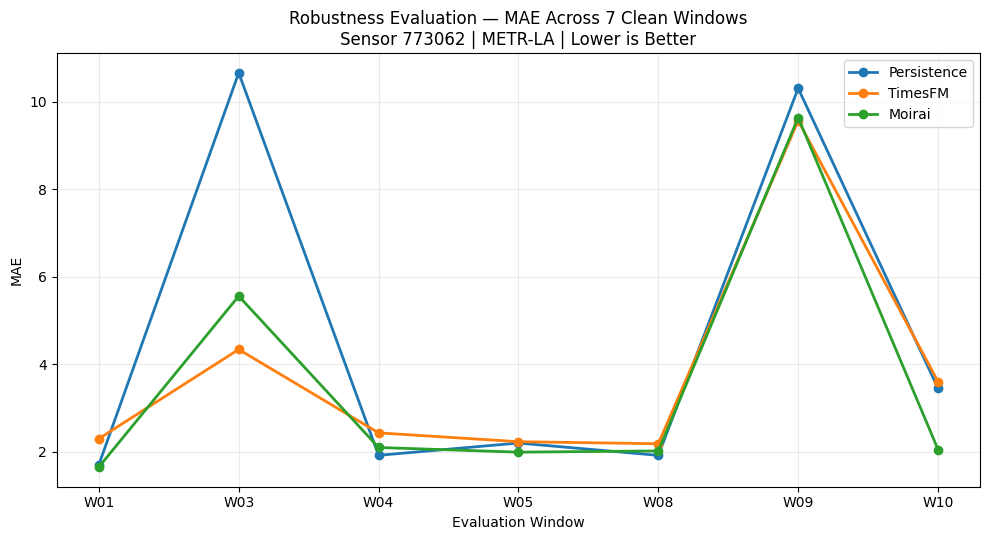

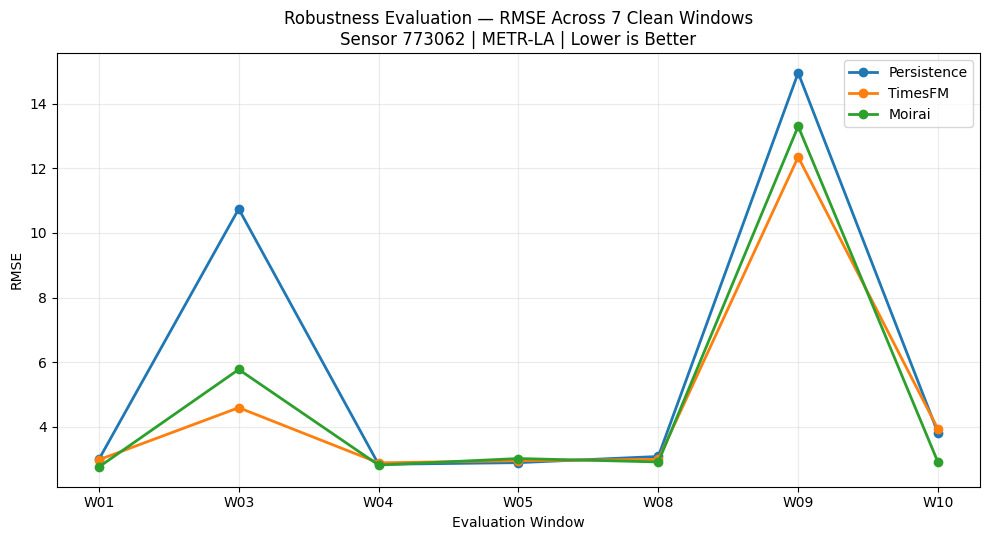

Saved:
✅ /content/robustness_mae_by_window.png
✅ /content/robustness_rmse_by_window.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ROBUSTNESS VISUALIZATION — PER WINDOW
# ============================================================

METRICS_PATH = "/content/robustness_final_metrics.csv"

df = pd.read_csv(METRICS_PATH)

WINDOW_ORDER = [
    "W01", "W03", "W04", "W05", "W08", "W09", "W10"
]

MODEL_ORDER = [
    "Persistence",
    "TimesFM",
    "Moirai",
]

df["window_id"] = pd.Categorical(
    df["window_id"],
    categories=WINDOW_ORDER,
    ordered=True
)

df = df.sort_values(
    ["window_id", "model"]
)

# ============================================================
# 1. MAE BY WINDOW
# ============================================================

plt.figure(figsize=(10, 5.5))

for model in MODEL_ORDER:

    subset = (
        df[df["model"] == model]
        .sort_values("window_id")
    )

    plt.plot(
        subset["window_id"].astype(str),
        subset["mae"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.xlabel("Evaluation Window")
plt.ylabel("MAE")
plt.title(
    "Robustness Evaluation — MAE Across 7 Clean Windows\n"
    "Sensor 773062 | METR-LA | Lower is Better"
)

plt.grid(
    True,
    alpha=0.25
)

plt.legend()
plt.tight_layout()

MAE_PATH = "/content/robustness_mae_by_window.png"

plt.savefig(
    MAE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 2. RMSE BY WINDOW
# ============================================================

plt.figure(figsize=(10, 5.5))

for model in MODEL_ORDER:

    subset = (
        df[df["model"] == model]
        .sort_values("window_id")
    )

    plt.plot(
        subset["window_id"].astype(str),
        subset["rmse"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.xlabel("Evaluation Window")
plt.ylabel("RMSE")
plt.title(
    "Robustness Evaluation — RMSE Across 7 Clean Windows\n"
    "Sensor 773062 | METR-LA | Lower is Better"
)

plt.grid(
    True,
    alpha=0.25
)

plt.legend()
plt.tight_layout()

RMSE_PATH = "/content/robustness_rmse_by_window.png"

plt.savefig(
    RMSE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("✅", MAE_PATH)
print("✅", RMSE_PATH)

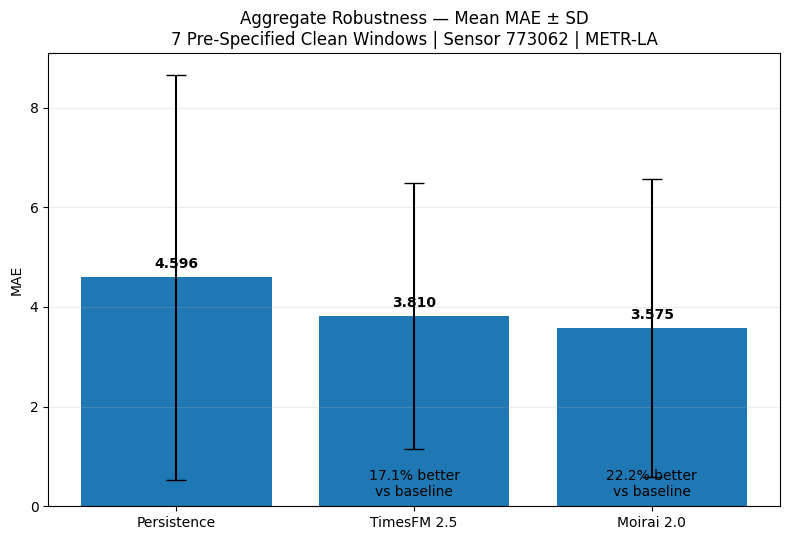

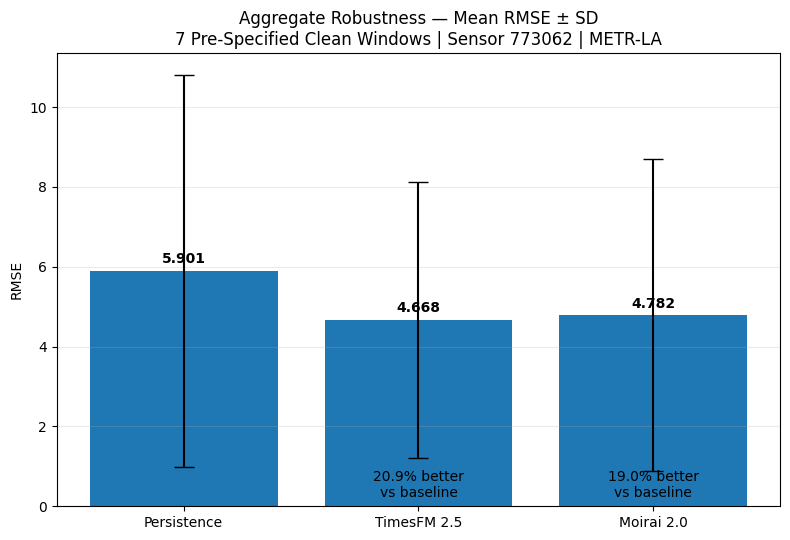

Saved:
✅ /content/aggregate_robustness_mae.png
✅ /content/aggregate_robustness_rmse.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# AGGREGATE ROBUSTNESS FIGURES
# Mean ± Standard Deviation across 7 clean windows
# ============================================================

SUMMARY_PATH = "/content/robustness_final_summary.csv"

summary = pd.read_csv(SUMMARY_PATH)

MODEL_ORDER = ["Persistence", "TimesFM", "Moirai"]
DISPLAY_NAMES = {
    "Persistence": "Persistence",
    "TimesFM": "TimesFM 2.5",
    "Moirai": "Moirai 2.0",
}

summary = (
    summary
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

labels = [DISPLAY_NAMES[m] for m in summary["model"]]
x = np.arange(len(labels))

# ============================================================
# 1. MEAN MAE ± STD
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

bars = ax.bar(
    x,
    summary["mean_mae"],
    yerr=summary["std_mae"],
    capsize=7
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("MAE")
ax.set_title(
    "Aggregate Robustness — Mean MAE ± SD\n"
    "7 Pre-Specified Clean Windows | Sensor 773062 | METR-LA"
)

ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, summary["mean_mae"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.12,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# Improvement annotations
for i, row in summary.iterrows():

    if row["model"] == "Persistence":
        continue

    improvement = row[
        "mean_mae_improvement_vs_persistence_pct"
    ]

    ax.text(
        i,
        0.15,
        f"{improvement:.1f}% better\nvs baseline",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

MAE_PATH = "/content/aggregate_robustness_mae.png"

plt.savefig(
    MAE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 2. MEAN RMSE ± STD
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

bars = ax.bar(
    x,
    summary["mean_rmse"],
    yerr=summary["std_rmse"],
    capsize=7
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("RMSE")
ax.set_title(
    "Aggregate Robustness — Mean RMSE ± SD\n"
    "7 Pre-Specified Clean Windows | Sensor 773062 | METR-LA"
)

ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, summary["mean_rmse"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.12,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

for i, row in summary.iterrows():

    if row["model"] == "Persistence":
        continue

    improvement = row[
        "mean_rmse_improvement_vs_persistence_pct"
    ]

    ax.text(
        i,
        0.15,
        f"{improvement:.1f}% better\nvs baseline",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

RMSE_PATH = "/content/aggregate_robustness_rmse.png"

plt.savefig(
    RMSE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print("✅", MAE_PATH)
print("✅", RMSE_PATH)

In [11]:
!pip install -q "timesfm[torch]==2.0.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


In [12]:
import timesfm, torch, importlib.metadata as metadata

print("TimesFM:", metadata.version("timesfm"))
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

TimesFM: 2.0.2
CUDA: True
GPU: Tesla T4


In [13]:
import numpy as np
import pandas as pd
import torch
import timesfm

# ============================================================
# W01 — TIMESFM 2.5 UNCERTAINTY
# ============================================================

WINDOWS_PATH = "/content/robustness_windows_sensor_773062.csv"
OLD_PRED_PATH = "/content/robustness_timesfm_predictions.csv"

# ------------------------------------------------------------
# 1. Load exact locked W01
# ------------------------------------------------------------

windows = pd.read_csv(
    WINDOWS_PATH,
    parse_dates=["timestamp"]
)

w01 = windows[
    windows["window_id"] == "W01"
].copy()

context_df = (
    w01[w01["split"] == "context"]
    .sort_values("timestamp")
)

gt_df = (
    w01[w01["split"] == "ground_truth"]
    .sort_values("timestamp")
)

context = context_df["traffic_speed"].to_numpy(
    dtype=np.float32
)

y_true = gt_df["traffic_speed"].to_numpy(
    dtype=np.float64
)

assert context.shape == (96,)
assert y_true.shape == (24,)

print("W01 locked data: OK")
print("Context:", context.shape)
print("Ground truth:", y_true.shape)

# ------------------------------------------------------------
# 2. Load EXACT same TimesFM 2.5 setup
# ------------------------------------------------------------

MODEL_ID = "google/timesfm-2.5-200m-pytorch"

print("\nLoading TimesFM 2.5...")

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    MODEL_ID
)

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

print("Model loaded: OK")

# ------------------------------------------------------------
# 3. Forecast W01 only
# ------------------------------------------------------------

with torch.no_grad():

    point_forecast, quantile_forecast = model.forecast(
        horizon=24,
        inputs=[context],
    )

point = np.asarray(
    point_forecast[0],
    dtype=np.float64
)

quantiles = np.asarray(
    quantile_forecast[0],
    dtype=np.float64
)

print("\nPoint shape:", point.shape)
print("Quantile shape:", quantiles.shape)

assert point.shape == (24,)
assert quantiles.shape == (24, 10)

# TimesFM 2.5:
# [:, 0] = mean
# [:, 1] = q10
# ...
# [:, 5] = q50
# ...
# [:, 9] = q90

q10 = quantiles[:, 1]
q50 = quantiles[:, 5]
q90 = quantiles[:, 9]

# ------------------------------------------------------------
# 4. Strict audits
# ------------------------------------------------------------

assert np.isfinite(q10).all()
assert np.isfinite(q50).all()
assert np.isfinite(q90).all()

point_q50_diff = np.max(
    np.abs(point - q50)
)

crossings = int(
    ((q10 > q50) | (q50 > q90)).sum()
)

print()
print("Point vs q50 max abs diff:", point_q50_diff)
print("Quantile crossings:", crossings)

assert np.allclose(
    point,
    q50,
    atol=1e-5,
    rtol=1e-5
)

assert crossings == 0

# ------------------------------------------------------------
# 5. Compare against PREVIOUS robustness W01 predictions
# ------------------------------------------------------------

old = pd.read_csv(
    OLD_PRED_PATH,
    parse_dates=["timestamp"]
)

old_w01 = (
    old[old["window_id"] == "W01"]
    .sort_values("timestamp")
)

assert len(old_w01) == 24

saved_prediction = old_w01[
    "timesfm_2_5"
].to_numpy(dtype=np.float64)

reproduction_diff = np.max(
    np.abs(q50 - saved_prediction)
)

print(
    "q50 vs saved W01 prediction max abs diff:",
    reproduction_diff
)

assert np.allclose(
    q50,
    saved_prediction,
    atol=1e-5,
    rtol=1e-5
)

# ------------------------------------------------------------
# 6. Save W01 uncertainty artifact
# ------------------------------------------------------------

out = pd.DataFrame({
    "timestamp": gt_df["timestamp"].to_numpy(),
    "ground_truth": y_true,
    "q10": q10,
    "q50": q50,
    "q90": q90,
})

out.to_csv(
    "/content/w01_timesfm_uncertainty.csv",
    index=False
)

print()
print("First 5 rows:")
print(out.head().to_string(index=False))

print()
print("✅ W01 TIMESFM q10/q50/q90 VALID")
print("✅ q50 REPRODUCES SAVED ROBUSTNESS FORECAST")
print("✅ Saved: /content/w01_timesfm_uncertainty.csv")

W01 locked data: OK
Context: (96,)
Ground truth: (24,)

Loading TimesFM 2.5...


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  925MB            

model.safetensors: downloading bytes:           |  0.00B            

Model loaded: OK

Point shape: (24,)
Quantile shape: (24, 10)

Point vs q50 max abs diff: 0.0
Quantile crossings: 0
q50 vs saved W01 prediction max abs diff: 7.105427357601002e-15

First 5 rows:
          timestamp  ground_truth       q10       q50       q90
2012-06-04 21:30:00        65.125 59.135674 64.801353 68.306717
2012-06-04 21:35:00        56.625 58.555271 64.737503 68.901352
2012-06-04 21:40:00        64.000 57.426594 64.308182 68.459290
2012-06-04 21:45:00        64.125 56.687538 64.160919 68.278008
2012-06-04 21:50:00        58.000 56.039642 63.873009 68.219543

✅ W01 TIMESFM q10/q50/q90 VALID
✅ q50 REPRODUCES SAVED ROBUSTNESS FORECAST
✅ Saved: /content/w01_timesfm_uncertainty.csv


In [14]:
import os

env_path = "/content/moirai2_robust_env"

print("Moirai environment exists:", os.path.exists(env_path))
print(
    "Python exists:",
    os.path.exists(f"{env_path}/bin/python")
)

Moirai environment exists: False
Python exists: False


In [15]:
# ============================================================
# RECREATE ISOLATED MOIRAI 2.0 ENVIRONMENT
# ============================================================

!rm -rf /content/moirai2_robust_env

!python -m pip install -q virtualenv
!python -m virtualenv /content/moirai2_robust_env

print("\n--- Installing PyTorch 2.4.1 CPU ---")

!/content/moirai2_robust_env/bin/pip install --no-cache-dir \
    "torch==2.4.1+cpu" \
    --index-url https://download.pytorch.org/whl/cpu

print("\n--- Installing Uni2TS 2.0.0 ---")

!/content/moirai2_robust_env/bin/pip install --no-cache-dir \
    "uni2ts==2.0.0"

print("\n--- Dependency audit ---")

!/content/moirai2_robust_env/bin/pip check

print("\n--- Version / API audit ---")

!/content/moirai2_robust_env/bin/python -c \
"import torch, importlib.metadata as m; \
from uni2ts.model.moirai2 import Moirai2Forecast, Moirai2Module; \
print('Torch:', torch.__version__); \
print('Uni2TS:', m.version('uni2ts')); \
print('Moirai 2 API: OK')"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 14.8 MB/s eta 0:00:00
created virtual environment CPython3.12.13.final.0-64-x86_64 in 495ms
  creator CPython3Posix(dest=/content/moirai2_robust_env, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.2.1
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator

--- Installing PyTorch 2.4.1 CPU ---
Looking in indexes: https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 164.4 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 405.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 427.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 499.6 MB/s  0:00:00
   ━━━

In [16]:
%%bash

/content/moirai2_robust_env/bin/python - <<'PY'

import numpy as np
import pandas as pd
import torch

from uni2ts.model.moirai2 import (
    Moirai2Forecast,
    Moirai2Module,
)

# ============================================================
# W01 — MOIRAI 2.0 UNCERTAINTY
# ============================================================

WINDOWS_PATH = "/content/robustness_windows_sensor_773062.csv"
OLD_PRED_PATH = "/content/robustness_moirai2_predictions.csv"
MODEL_ID = "Salesforce/moirai-2.0-R-small"

# ------------------------------------------------------------
# 1. Load exact locked W01
# ------------------------------------------------------------

windows = pd.read_csv(
    WINDOWS_PATH,
    parse_dates=["timestamp"]
)

w01 = windows[
    windows["window_id"] == "W01"
].copy()

context_df = (
    w01[w01["split"] == "context"]
    .sort_values("timestamp")
)

gt_df = (
    w01[w01["split"] == "ground_truth"]
    .sort_values("timestamp")
)

context = context_df["traffic_speed"].to_numpy(
    dtype=np.float32
)

y_true = gt_df["traffic_speed"].to_numpy(
    dtype=np.float64
)

assert context.shape == (96,)
assert y_true.shape == (24,)

print("W01 locked data: OK")
print("Context:", context.shape)
print("Ground truth:", y_true.shape)

# ------------------------------------------------------------
# 2. Load EXACT same Moirai 2.0 setup
# ------------------------------------------------------------

print("\nLoading Moirai 2.0...")

module = Moirai2Module.from_pretrained(
    MODEL_ID
)

model = Moirai2Forecast(
    module=module,
    prediction_length=24,
    context_length=96,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

model = model.to("cpu")
model.eval()

levels = list(module.quantile_levels)

print("Quantiles:", levels)

assert levels == [
    0.1, 0.2, 0.3, 0.4, 0.5,
    0.6, 0.7, 0.8, 0.9
]

q10_idx = levels.index(0.1)
q50_idx = levels.index(0.5)
q90_idx = levels.index(0.9)

# ------------------------------------------------------------
# 3. Forecast W01 only
# ------------------------------------------------------------

with torch.no_grad():
    forecast = model.predict([context])

forecast = np.asarray(
    forecast,
    dtype=np.float64
)

print("\nForecast shape:", forecast.shape)

assert forecast.shape == (1, 9, 24)

q10 = forecast[0, q10_idx, :]
q50 = forecast[0, q50_idx, :]
q90 = forecast[0, q90_idx, :]

assert np.isfinite(q10).all()
assert np.isfinite(q50).all()
assert np.isfinite(q90).all()

crossings = int(
    ((q10 > q50) | (q50 > q90)).sum()
)

print("Quantile crossings:", crossings)

assert crossings == 0

# ------------------------------------------------------------
# 4. Compare q50 with PREVIOUS saved robustness forecast
# ------------------------------------------------------------

old = pd.read_csv(
    OLD_PRED_PATH,
    parse_dates=["timestamp"]
)

old_w01 = (
    old[old["window_id"] == "W01"]
    .sort_values("timestamp")
)

assert len(old_w01) == 24

saved_prediction = old_w01[
    "moirai_2_0"
].to_numpy(dtype=np.float64)

reproduction_diff = float(
    np.max(np.abs(q50 - saved_prediction))
)

print(
    "q50 vs saved W01 prediction max abs diff:",
    reproduction_diff
)

assert np.allclose(
    q50,
    saved_prediction,
    atol=1e-5,
    rtol=1e-5
)

# ------------------------------------------------------------
# 5. Save W01 uncertainty artifact
# ------------------------------------------------------------

out = pd.DataFrame({
    "timestamp": gt_df["timestamp"].to_numpy(),
    "ground_truth": y_true,
    "q10": q10,
    "q50": q50,
    "q90": q90,
})

out.to_csv(
    "/content/w01_moirai2_uncertainty.csv",
    index=False
)

print()
print("First 5 rows:")
print(out.head().to_string(index=False))

print()
print("✅ W01 MOIRAI q10/q50/q90 VALID")
print("✅ q50 REPRODUCES SAVED ROBUSTNESS FORECAST")
print("✅ Saved: /content/w01_moirai2_uncertainty.csv")

PY

W01 locked data: OK
Context: (96,)
Ground truth: (24,)

Loading Moirai 2.0...
Quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

Forecast shape: (1, 9, 24)
Quantile crossings: 0
q50 vs saved W01 prediction max abs diff: 0.0

First 5 rows:
          timestamp  ground_truth       q10       q50       q90
2012-06-04 21:30:00        65.125 60.198067 64.816544 68.342422
2012-06-04 21:35:00        56.625 59.603127 64.957306 68.501640
2012-06-04 21:40:00        64.000 59.202820 65.038628 68.794296
2012-06-04 21:45:00        64.125 58.752670 65.114449 69.072403
2012-06-04 21:50:00        58.000 58.490723 64.970589 69.104782

✅ W01 MOIRAI q10/q50/q90 VALID
✅ q50 REPRODUCES SAVED ROBUSTNESS FORECAST
✅ Saved: /content/w01_moirai2_uncertainty.csv


✅ W01 uncertainty inputs verified
TimesFM empirical q10-q90 coverage: 95.8%
Moirai empirical q10-q90 coverage: 91.7%
TimesFM mean interval width: 15.950
Moirai mean interval width: 13.350


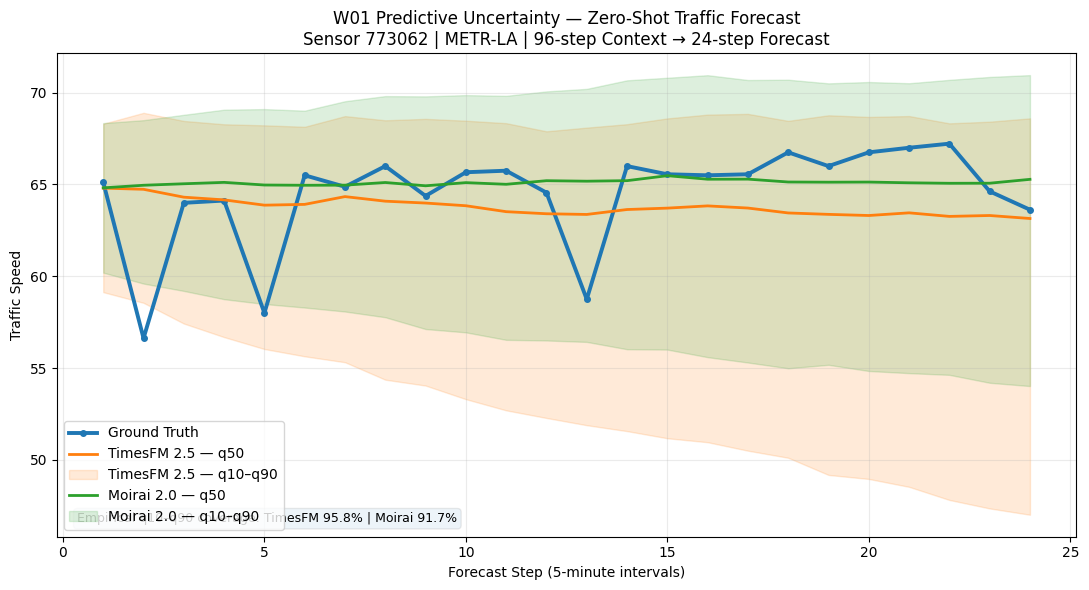


✅ Saved: /content/w01_uncertainty_comparison.png


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# W01 — FINAL UNCERTAINTY COMPARISON
# ============================================================

tf = pd.read_csv(
    "/content/w01_timesfm_uncertainty.csv",
    parse_dates=["timestamp"]
)

mo = pd.read_csv(
    "/content/w01_moirai2_uncertainty.csv",
    parse_dates=["timestamp"]
)

# ------------------------------------------------------------
# 1. Strict integrity checks
# ------------------------------------------------------------

assert len(tf) == 24
assert len(mo) == 24

assert tf["timestamp"].tolist() == mo["timestamp"].tolist()

assert np.allclose(
    tf["ground_truth"].to_numpy(),
    mo["ground_truth"].to_numpy()
)

assert (tf["q10"] <= tf["q50"]).all()
assert (tf["q50"] <= tf["q90"]).all()

assert (mo["q10"] <= mo["q50"]).all()
assert (mo["q50"] <= mo["q90"]).all()

print("✅ W01 uncertainty inputs verified")

# ------------------------------------------------------------
# 2. Descriptive empirical coverage
# ------------------------------------------------------------

tf_inside = (
    (tf["ground_truth"] >= tf["q10"]) &
    (tf["ground_truth"] <= tf["q90"])
)

mo_inside = (
    (mo["ground_truth"] >= mo["q10"]) &
    (mo["ground_truth"] <= mo["q90"])
)

tf_coverage = float(tf_inside.mean())
mo_coverage = float(mo_inside.mean())

tf_width = float(
    (tf["q90"] - tf["q10"]).mean()
)

mo_width = float(
    (mo["q90"] - mo["q10"]).mean()
)

print(
    f"TimesFM empirical q10-q90 coverage: "
    f"{tf_coverage*100:.1f}%"
)

print(
    f"Moirai empirical q10-q90 coverage: "
    f"{mo_coverage*100:.1f}%"
)

print(
    f"TimesFM mean interval width: "
    f"{tf_width:.3f}"
)

print(
    f"Moirai mean interval width: "
    f"{mo_width:.3f}"
)

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------

x = np.arange(1, 25)

fig, ax = plt.subplots(figsize=(11, 6))

# Ground truth
ax.plot(
    x,
    tf["ground_truth"],
    marker="o",
    markersize=4,
    linewidth=2.8,
    label="Ground Truth"
)

# TimesFM
tf_line, = ax.plot(
    x,
    tf["q50"],
    linewidth=2,
    label="TimesFM 2.5 — q50"
)

ax.fill_between(
    x,
    tf["q10"],
    tf["q90"],
    color=tf_line.get_color(),
    alpha=0.16,
    label="TimesFM 2.5 — q10–q90"
)

# Moirai
mo_line, = ax.plot(
    x,
    mo["q50"],
    linewidth=2,
    label="Moirai 2.0 — q50"
)

ax.fill_between(
    x,
    mo["q10"],
    mo["q90"],
    color=mo_line.get_color(),
    alpha=0.16,
    label="Moirai 2.0 — q10–q90"
)

ax.set_xlabel(
    "Forecast Step (5-minute intervals)"
)

ax.set_ylabel(
    "Traffic Speed"
)

ax.set_title(
    "W01 Predictive Uncertainty — Zero-Shot Traffic Forecast\n"
    "Sensor 773062 | METR-LA | 96-step Context → 24-step Forecast"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    loc="best"
)

ax.text(
    0.02,
    0.03,
    (
        f"Empirical q10–q90 coverage: "
        f"TimesFM {tf_coverage*100:.1f}% | "
        f"Moirai {mo_coverage*100:.1f}%"
    ),
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(
        boxstyle="round",
        alpha=0.08
    )
)

plt.tight_layout()

OUT_PATH = "/content/w01_uncertainty_comparison.png"

plt.savefig(
    OUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("✅ Saved:", OUT_PATH)

In [18]:
import pandas as pd
import numpy as np

# ============================================================
# W01 UNCERTAINTY — FINAL NUMERIC SUMMARY
# ============================================================

tf = pd.read_csv(
    "/content/w01_timesfm_uncertainty.csv"
)

mo = pd.read_csv(
    "/content/w01_moirai2_uncertainty.csv"
)

assert len(tf) == 24
assert len(mo) == 24

assert np.allclose(
    tf["ground_truth"],
    mo["ground_truth"]
)

# ------------------------------------------------------------
# TimesFM 2.5
# ------------------------------------------------------------

tf_inside = (
    (tf["ground_truth"] >= tf["q10"]) &
    (tf["ground_truth"] <= tf["q90"])
)

tf_coverage = float(tf_inside.mean())
tf_mean_width = float(
    (tf["q90"] - tf["q10"]).mean()
)
tf_median_width = float(
    (tf["q90"] - tf["q10"]).median()
)

# ------------------------------------------------------------
# Moirai 2.0
# ------------------------------------------------------------

mo_inside = (
    (mo["ground_truth"] >= mo["q10"]) &
    (mo["ground_truth"] <= mo["q90"])
)

mo_coverage = float(mo_inside.mean())
mo_mean_width = float(
    (mo["q90"] - mo["q10"]).mean()
)
mo_median_width = float(
    (mo["q90"] - mo["q10"]).median()
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

summary = pd.DataFrame([
    {
        "model": "TimesFM 2.5",
        "window_id": "W01",
        "forecast_points": 24,
        "q10_q90_covered_points": int(tf_inside.sum()),
        "empirical_q10_q90_coverage": tf_coverage,
        "mean_interval_width": tf_mean_width,
        "median_interval_width": tf_median_width,
    },
    {
        "model": "Moirai 2.0",
        "window_id": "W01",
        "forecast_points": 24,
        "q10_q90_covered_points": int(mo_inside.sum()),
        "empirical_q10_q90_coverage": mo_coverage,
        "mean_interval_width": mo_mean_width,
        "median_interval_width": mo_median_width,
    }
])

summary.to_csv(
    "/content/w01_uncertainty_summary.csv",
    index=False
)

print("======================================")
print("W01 UNCERTAINTY SUMMARY")
print("======================================")
print()
print(summary.to_string(index=False))

print()
print(
    f"TimesFM coverage: "
    f"{tf_inside.sum()}/24 "
    f"({tf_coverage*100:.1f}%)"
)

print(
    f"Moirai coverage: "
    f"{mo_inside.sum()}/24 "
    f"({mo_coverage*100:.1f}%)"
)

print()
print(
    f"TimesFM mean interval width: "
    f"{tf_mean_width:.4f}"
)

print(
    f"Moirai mean interval width: "
    f"{mo_mean_width:.4f}"
)

print()
print("✅ W01 UNCERTAINTY SUMMARY VERIFIED")
print("✅ Saved: /content/w01_uncertainty_summary.csv")

W01 UNCERTAINTY SUMMARY

      model window_id  forecast_points  q10_q90_covered_points  empirical_q10_q90_coverage  mean_interval_width  median_interval_width
TimesFM 2.5       W01               24                      23                    0.958333            15.949596              15.921812
 Moirai 2.0       W01               24                      22                    0.916667            13.349850              13.671310

TimesFM coverage: 23/24 (95.8%)
Moirai coverage: 22/24 (91.7%)

TimesFM mean interval width: 15.9496
Moirai mean interval width: 13.3498

✅ W01 UNCERTAINTY SUMMARY VERIFIED
✅ Saved: /content/w01_uncertainty_summary.csv


In [19]:
import os
import zipfile

files_to_save = [
    "/content/w01_timesfm_uncertainty.csv",
    "/content/w01_moirai2_uncertainty.csv",
    "/content/w01_uncertainty_summary.csv",
    "/content/w01_uncertainty_comparison.png",
]

for path in files_to_save:
    assert os.path.exists(path), f"Missing: {path}"

ZIP_PATH = "/content/w01_uncertainty_COMPLETE.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as z:
    for path in files_to_save:
        z.write(path, arcname=os.path.basename(path))

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    assert len(z.namelist()) == 4

print("✅ W01 UNCERTAINTY BACKUP COMPLETE")
print("Files:", len(files_to_save))
print("Saved:", ZIP_PATH)

✅ W01 UNCERTAINTY BACKUP COMPLETE
Files: 4
Saved: /content/w01_uncertainty_COMPLETE.zip


In [20]:
import numpy as np
import pandas as pd
import torch

# ============================================================
# W09 — TIMESFM 2.5 UNCERTAINTY
# ============================================================

WINDOWS_PATH = "/content/robustness_windows_sensor_773062.csv"
OLD_PRED_PATH = "/content/robustness_timesfm_predictions.csv"

# TimesFM model should still be loaded from W01
assert "model" in globals(), \
    "TimesFM model is no longer in memory."

# ------------------------------------------------------------
# 1. Load exact locked W09
# ------------------------------------------------------------

windows = pd.read_csv(
    WINDOWS_PATH,
    parse_dates=["timestamp"]
)

w09 = windows[
    windows["window_id"] == "W09"
].copy()

context_df = (
    w09[w09["split"] == "context"]
    .sort_values("timestamp")
)

gt_df = (
    w09[w09["split"] == "ground_truth"]
    .sort_values("timestamp")
)

context = context_df["traffic_speed"].to_numpy(
    dtype=np.float32
)

y_true = gt_df["traffic_speed"].to_numpy(
    dtype=np.float64
)

assert context.shape == (96,)
assert y_true.shape == (24,)

print("W09 locked data: OK")
print("Context:", context.shape)
print("Ground truth:", y_true.shape)

# ------------------------------------------------------------
# 2. Forecast
# ------------------------------------------------------------

with torch.no_grad():
    point_forecast, quantile_forecast = model.forecast(
        horizon=24,
        inputs=[context],
    )

point = np.asarray(
    point_forecast[0],
    dtype=np.float64
)

quantiles = np.asarray(
    quantile_forecast[0],
    dtype=np.float64
)

print()
print("Point shape:", point.shape)
print("Quantile shape:", quantiles.shape)

assert point.shape == (24,)
assert quantiles.shape == (24, 10)

q10 = quantiles[:, 1]
q50 = quantiles[:, 5]
q90 = quantiles[:, 9]

# ------------------------------------------------------------
# 3. Audit
# ------------------------------------------------------------

assert np.isfinite(q10).all()
assert np.isfinite(q50).all()
assert np.isfinite(q90).all()

point_q50_diff = float(
    np.max(np.abs(point - q50))
)

crossings = int(
    ((q10 > q50) | (q50 > q90)).sum()
)

print("Point vs q50 max abs diff:", point_q50_diff)
print("Quantile crossings:", crossings)

assert np.allclose(
    point,
    q50,
    atol=1e-5,
    rtol=1e-5
)

assert crossings == 0

# ------------------------------------------------------------
# 4. Reproduce previous W09 prediction
# ------------------------------------------------------------

old = pd.read_csv(
    OLD_PRED_PATH,
    parse_dates=["timestamp"]
)

old_w09 = (
    old[old["window_id"] == "W09"]
    .sort_values("timestamp")
)

assert len(old_w09) == 24

saved_prediction = old_w09[
    "timesfm_2_5"
].to_numpy(dtype=np.float64)

reproduction_diff = float(
    np.max(np.abs(q50 - saved_prediction))
)

print(
    "q50 vs saved W09 prediction max abs diff:",
    reproduction_diff
)

assert np.allclose(
    q50,
    saved_prediction,
    atol=1e-5,
    rtol=1e-5
)

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

out = pd.DataFrame({
    "timestamp": gt_df["timestamp"].to_numpy(),
    "ground_truth": y_true,
    "q10": q10,
    "q50": q50,
    "q90": q90,
})

out.to_csv(
    "/content/w09_timesfm_uncertainty.csv",
    index=False
)

print()
print("✅ W09 TIMESFM q10/q50/q90 VALID")
print("✅ q50 REPRODUCES SAVED ROBUSTNESS FORECAST")
print("✅ Saved: /content/w09_timesfm_uncertainty.csv")

W09 locked data: OK
Context: (96,)
Ground truth: (24,)

Point shape: (24,)
Quantile shape: (24, 10)
Point vs q50 max abs diff: 0.0
Quantile crossings: 0
q50 vs saved W09 prediction max abs diff: 7.105427357601002e-15

✅ W09 TIMESFM q10/q50/q90 VALID
✅ q50 REPRODUCES SAVED ROBUSTNESS FORECAST
✅ Saved: /content/w09_timesfm_uncertainty.csv


In [21]:
%%bash

/content/moirai2_robust_env/bin/python - <<'PY'

import numpy as np
import pandas as pd
import torch

from uni2ts.model.moirai2 import (
    Moirai2Forecast,
    Moirai2Module,
)

WINDOWS_PATH = "/content/robustness_windows_sensor_773062.csv"
OLD_PRED_PATH = "/content/robustness_moirai2_predictions.csv"
MODEL_ID = "Salesforce/moirai-2.0-R-small"

# ------------------------------------------------------------
# 1. Load exact locked W09
# ------------------------------------------------------------

windows = pd.read_csv(
    WINDOWS_PATH,
    parse_dates=["timestamp"]
)

w09 = windows[
    windows["window_id"] == "W09"
].copy()

context_df = (
    w09[w09["split"] == "context"]
    .sort_values("timestamp")
)

gt_df = (
    w09[w09["split"] == "ground_truth"]
    .sort_values("timestamp")
)

context = context_df["traffic_speed"].to_numpy(
    dtype=np.float32
)

y_true = gt_df["traffic_speed"].to_numpy(
    dtype=np.float64
)

assert context.shape == (96,)
assert y_true.shape == (24,)

print("W09 locked data: OK")
print("Context:", context.shape)
print("Ground truth:", y_true.shape)

# ------------------------------------------------------------
# 2. Load Moirai 2.0
# ------------------------------------------------------------

print("\nLoading Moirai 2.0...")

module = Moirai2Module.from_pretrained(
    MODEL_ID
)

model = Moirai2Forecast(
    module=module,
    prediction_length=24,
    context_length=96,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

model = model.to("cpu")
model.eval()

levels = list(module.quantile_levels)

assert levels == [
    0.1, 0.2, 0.3, 0.4, 0.5,
    0.6, 0.7, 0.8, 0.9
]

q10_idx = levels.index(0.1)
q50_idx = levels.index(0.5)
q90_idx = levels.index(0.9)

# ------------------------------------------------------------
# 3. Forecast W09
# ------------------------------------------------------------

with torch.no_grad():
    forecast = model.predict([context])

forecast = np.asarray(
    forecast,
    dtype=np.float64
)

print("\nForecast shape:", forecast.shape)

assert forecast.shape == (1, 9, 24)

q10 = forecast[0, q10_idx, :]
q50 = forecast[0, q50_idx, :]
q90 = forecast[0, q90_idx, :]

assert np.isfinite(q10).all()
assert np.isfinite(q50).all()
assert np.isfinite(q90).all()

crossings = int(
    ((q10 > q50) | (q50 > q90)).sum()
)

print("Quantile crossings:", crossings)

assert crossings == 0

# ------------------------------------------------------------
# 4. Reproduce saved W09 forecast
# ------------------------------------------------------------

old = pd.read_csv(
    OLD_PRED_PATH,
    parse_dates=["timestamp"]
)

old_w09 = (
    old[old["window_id"] == "W09"]
    .sort_values("timestamp")
)

assert len(old_w09) == 24

saved_prediction = old_w09[
    "moirai_2_0"
].to_numpy(dtype=np.float64)

reproduction_diff = float(
    np.max(np.abs(q50 - saved_prediction))
)

print(
    "q50 vs saved W09 prediction max abs diff:",
    reproduction_diff
)

assert np.allclose(
    q50,
    saved_prediction,
    atol=1e-5,
    rtol=1e-5
)

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

out = pd.DataFrame({
    "timestamp": gt_df["timestamp"].to_numpy(),
    "ground_truth": y_true,
    "q10": q10,
    "q50": q50,
    "q90": q90,
})

out.to_csv(
    "/content/w09_moirai2_uncertainty.csv",
    index=False
)

print()
print("✅ W09 MOIRAI q10/q50/q90 VALID")
print("✅ q50 REPRODUCES SAVED ROBUSTNESS FORECAST")
print("✅ Saved: /content/w09_moirai2_uncertainty.csv")

PY

W09 locked data: OK
Context: (96,)
Ground truth: (24,)

Loading Moirai 2.0...

Forecast shape: (1, 9, 24)
Quantile crossings: 0
q50 vs saved W09 prediction max abs diff: 7.105427357601002e-15

✅ W09 MOIRAI q10/q50/q90 VALID
✅ q50 REPRODUCES SAVED ROBUSTNESS FORECAST
✅ Saved: /content/w09_moirai2_uncertainty.csv


✅ W09 uncertainty inputs verified
TimesFM empirical q10-q90 coverage: 18/24 (75.0%)
Moirai empirical q10-q90 coverage: 19/24 (79.2%)
TimesFM mean interval width: 28.0303
Moirai mean interval width: 26.8294


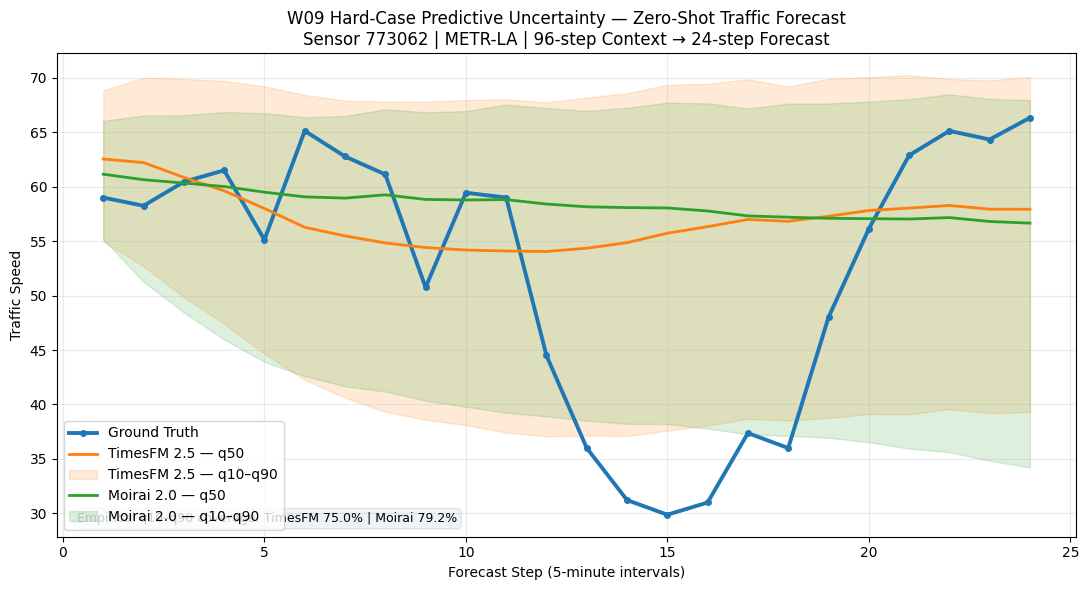


✅ Saved: /content/w09_uncertainty_comparison.png


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# W09 — HARD-CASE UNCERTAINTY COMPARISON
# ============================================================

tf = pd.read_csv(
    "/content/w09_timesfm_uncertainty.csv",
    parse_dates=["timestamp"]
)

mo = pd.read_csv(
    "/content/w09_moirai2_uncertainty.csv",
    parse_dates=["timestamp"]
)

# ------------------------------------------------------------
# 1. STRICT INTEGRITY CHECK
# ------------------------------------------------------------

assert len(tf) == 24
assert len(mo) == 24

assert tf["timestamp"].tolist() == mo["timestamp"].tolist()

assert np.allclose(
    tf["ground_truth"].to_numpy(),
    mo["ground_truth"].to_numpy()
)

assert (tf["q10"] <= tf["q50"]).all()
assert (tf["q50"] <= tf["q90"]).all()

assert (mo["q10"] <= mo["q50"]).all()
assert (mo["q50"] <= mo["q90"]).all()

print("✅ W09 uncertainty inputs verified")

# ------------------------------------------------------------
# 2. DESCRIPTIVE UNCERTAINTY METRICS
# ------------------------------------------------------------

tf_inside = (
    (tf["ground_truth"] >= tf["q10"]) &
    (tf["ground_truth"] <= tf["q90"])
)

mo_inside = (
    (mo["ground_truth"] >= mo["q10"]) &
    (mo["ground_truth"] <= mo["q90"])
)

tf_coverage = float(tf_inside.mean())
mo_coverage = float(mo_inside.mean())

tf_width = float(
    (tf["q90"] - tf["q10"]).mean()
)

mo_width = float(
    (mo["q90"] - mo["q10"]).mean()
)

print(
    f"TimesFM empirical q10-q90 coverage: "
    f"{tf_inside.sum()}/24 ({tf_coverage*100:.1f}%)"
)

print(
    f"Moirai empirical q10-q90 coverage: "
    f"{mo_inside.sum()}/24 ({mo_coverage*100:.1f}%)"
)

print(
    f"TimesFM mean interval width: {tf_width:.4f}"
)

print(
    f"Moirai mean interval width: {mo_width:.4f}"
)

# ------------------------------------------------------------
# 3. PLOT
# ------------------------------------------------------------

x = np.arange(1, 25)

fig, ax = plt.subplots(figsize=(11, 6))

# Ground Truth
ax.plot(
    x,
    tf["ground_truth"],
    marker="o",
    markersize=4,
    linewidth=2.8,
    label="Ground Truth"
)

# TimesFM
tf_line, = ax.plot(
    x,
    tf["q50"],
    linewidth=2,
    label="TimesFM 2.5 — q50"
)

ax.fill_between(
    x,
    tf["q10"],
    tf["q90"],
    color=tf_line.get_color(),
    alpha=0.16,
    label="TimesFM 2.5 — q10–q90"
)

# Moirai
mo_line, = ax.plot(
    x,
    mo["q50"],
    linewidth=2,
    label="Moirai 2.0 — q50"
)

ax.fill_between(
    x,
    mo["q10"],
    mo["q90"],
    color=mo_line.get_color(),
    alpha=0.16,
    label="Moirai 2.0 — q10–q90"
)

ax.set_xlabel(
    "Forecast Step (5-minute intervals)"
)

ax.set_ylabel(
    "Traffic Speed"
)

ax.set_title(
    "W09 Hard-Case Predictive Uncertainty — Zero-Shot Traffic Forecast\n"
    "Sensor 773062 | METR-LA | 96-step Context → 24-step Forecast"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    loc="best"
)

ax.text(
    0.02,
    0.03,
    (
        f"Empirical q10–q90 coverage: "
        f"TimesFM {tf_coverage*100:.1f}% | "
        f"Moirai {mo_coverage*100:.1f}%"
    ),
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(
        boxstyle="round",
        alpha=0.08
    )
)

plt.tight_layout()

OUT_PATH = "/content/w09_uncertainty_comparison.png"

plt.savefig(
    OUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("✅ Saved:", OUT_PATH)

In [23]:
import pandas as pd
import numpy as np

tf = pd.read_csv("/content/w09_timesfm_uncertainty.csv")
mo = pd.read_csv("/content/w09_moirai2_uncertainty.csv")

assert len(tf) == 24
assert len(mo) == 24
assert np.allclose(tf["ground_truth"], mo["ground_truth"])

rows = []

for model_name, df in [
    ("TimesFM 2.5", tf),
    ("Moirai 2.0", mo),
]:
    inside = (
        (df["ground_truth"] >= df["q10"]) &
        (df["ground_truth"] <= df["q90"])
    )

    width = df["q90"] - df["q10"]

    rows.append({
        "model": model_name,
        "window_id": "W09",
        "forecast_points": 24,
        "q10_q90_covered_points": int(inside.sum()),
        "empirical_q10_q90_coverage": float(inside.mean()),
        "mean_interval_width": float(width.mean()),
        "median_interval_width": float(width.median()),
    })

summary = pd.DataFrame(rows)

summary.to_csv(
    "/content/w09_uncertainty_summary.csv",
    index=False
)

print("======================================")
print("W09 UNCERTAINTY SUMMARY")
print("======================================")
print()
print(summary.to_string(index=False))
print()
print("✅ W09 UNCERTAINTY SUMMARY VERIFIED")
print("✅ Saved: /content/w09_uncertainty_summary.csv")

W09 UNCERTAINTY SUMMARY

      model window_id  forecast_points  q10_q90_covered_points  empirical_q10_q90_coverage  mean_interval_width  median_interval_width
TimesFM 2.5       W09               24                      18                    0.750000            28.030282              30.586632
 Moirai 2.0       W09               24                      19                    0.791667            26.829357              28.382833

✅ W09 UNCERTAINTY SUMMARY VERIFIED
✅ Saved: /content/w09_uncertainty_summary.csv


In [24]:
import pandas as pd

# ============================================================
# W01 + W09 — FINAL UNCERTAINTY COMPARISON
# ============================================================

w01 = pd.read_csv(
    "/content/w01_uncertainty_summary.csv"
)

w09 = pd.read_csv(
    "/content/w09_uncertainty_summary.csv"
)

# ------------------------------------------------------------
# 1. Integrity check
# ------------------------------------------------------------

assert len(w01) == 2
assert len(w09) == 2

assert set(w01["model"]) == {
    "TimesFM 2.5",
    "Moirai 2.0"
}

assert set(w09["model"]) == {
    "TimesFM 2.5",
    "Moirai 2.0"
}

combined = pd.concat(
    [w01, w09],
    ignore_index=True
)

# ------------------------------------------------------------
# 2. Compare representative vs hard case
# ------------------------------------------------------------

comparison_rows = []

for model in ["TimesFM 2.5", "Moirai 2.0"]:

    a = w01[w01["model"] == model].iloc[0]
    b = w09[w09["model"] == model].iloc[0]

    coverage_change_pp = (
        b["empirical_q10_q90_coverage"]
        - a["empirical_q10_q90_coverage"]
    ) * 100

    width_change_pct = (
        (
            b["mean_interval_width"]
            / a["mean_interval_width"]
        ) - 1
    ) * 100

    comparison_rows.append({
        "model": model,

        "w01_coverage_pct":
            a["empirical_q10_q90_coverage"] * 100,

        "w09_coverage_pct":
            b["empirical_q10_q90_coverage"] * 100,

        "coverage_change_percentage_points":
            coverage_change_pp,

        "w01_mean_interval_width":
            a["mean_interval_width"],

        "w09_mean_interval_width":
            b["mean_interval_width"],

        "interval_width_change_pct":
            width_change_pct,
    })

comparison = pd.DataFrame(comparison_rows)

# ------------------------------------------------------------
# 3. Save
# ------------------------------------------------------------

combined.to_csv(
    "/content/uncertainty_w01_w09_all_results.csv",
    index=False
)

comparison.to_csv(
    "/content/uncertainty_w01_w09_comparison.csv",
    index=False
)

# ------------------------------------------------------------
# 4. Report
# ------------------------------------------------------------

print("============================================")
print("W01 → W09 UNCERTAINTY STRESS COMPARISON")
print("============================================")
print()

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

print()
print("✅ W01 + W09 UNCERTAINTY RESULTS VERIFIED")
print("✅ Saved: uncertainty_w01_w09_all_results.csv")
print("✅ Saved: uncertainty_w01_w09_comparison.csv")

W01 → W09 UNCERTAINTY STRESS COMPARISON

      model  w01_coverage_pct  w09_coverage_pct  coverage_change_percentage_points  w01_mean_interval_width  w09_mean_interval_width  interval_width_change_pct
TimesFM 2.5            95.833            75.000                            -20.833                   15.950                   28.030                     75.743
 Moirai 2.0            91.667            79.167                            -12.500                   13.350                   26.829                    100.971

✅ W01 + W09 UNCERTAINTY RESULTS VERIFIED
✅ Saved: uncertainty_w01_w09_all_results.csv
✅ Saved: uncertainty_w01_w09_comparison.csv


In [25]:
import os
import zipfile

files_to_save = [
    # W01
    "/content/w01_timesfm_uncertainty.csv",
    "/content/w01_moirai2_uncertainty.csv",
    "/content/w01_uncertainty_summary.csv",
    "/content/w01_uncertainty_comparison.png",

    # W09
    "/content/w09_timesfm_uncertainty.csv",
    "/content/w09_moirai2_uncertainty.csv",
    "/content/w09_uncertainty_summary.csv",
    "/content/w09_uncertainty_comparison.png",

    # Combined analysis
    "/content/uncertainty_w01_w09_all_results.csv",
    "/content/uncertainty_w01_w09_comparison.csv",
]

missing = [
    p for p in files_to_save
    if not os.path.exists(p)
]

print("Missing:", len(missing))

for p in missing:
    print("❌", p)

assert len(missing) == 0

ZIP_PATH = "/content/urbanverse_uncertainty_COMPLETE.zip"

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as z:
    for path in files_to_save:
        z.write(
            path,
            arcname=os.path.basename(path)
        )

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    contents = z.namelist()

assert len(contents) == 10

print()
print("✅ UNCERTAINTY PACKAGE COMPLETE")
print("Files inside ZIP:", len(contents))
print("Saved:", ZIP_PATH)

Missing: 0

✅ UNCERTAINTY PACKAGE COMPLETE
Files inside ZIP: 10
Saved: /content/urbanverse_uncertainty_COMPLETE.zip
